In [51]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [52]:
from typing import Optional

from IPython.display import Image
from matplotlib.ticker import MaxNLocator
from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import MSTL, STL
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from utilsforecast.losses import rmse, mae
from utilsforecast.evaluation import evaluate

In [53]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


# Exercises for Chapter 9

#### 1. the ACFs for 36 random numbers, 360 random numbers and 1,000 random numbers in following figures. 

a. Explain the differences among these figures. Do they all indicate that the data are white noise?

b. Why are the critical values at different distances from the mean of zero? Why are the autocorrelations different in each figure when they each refer to white noise?

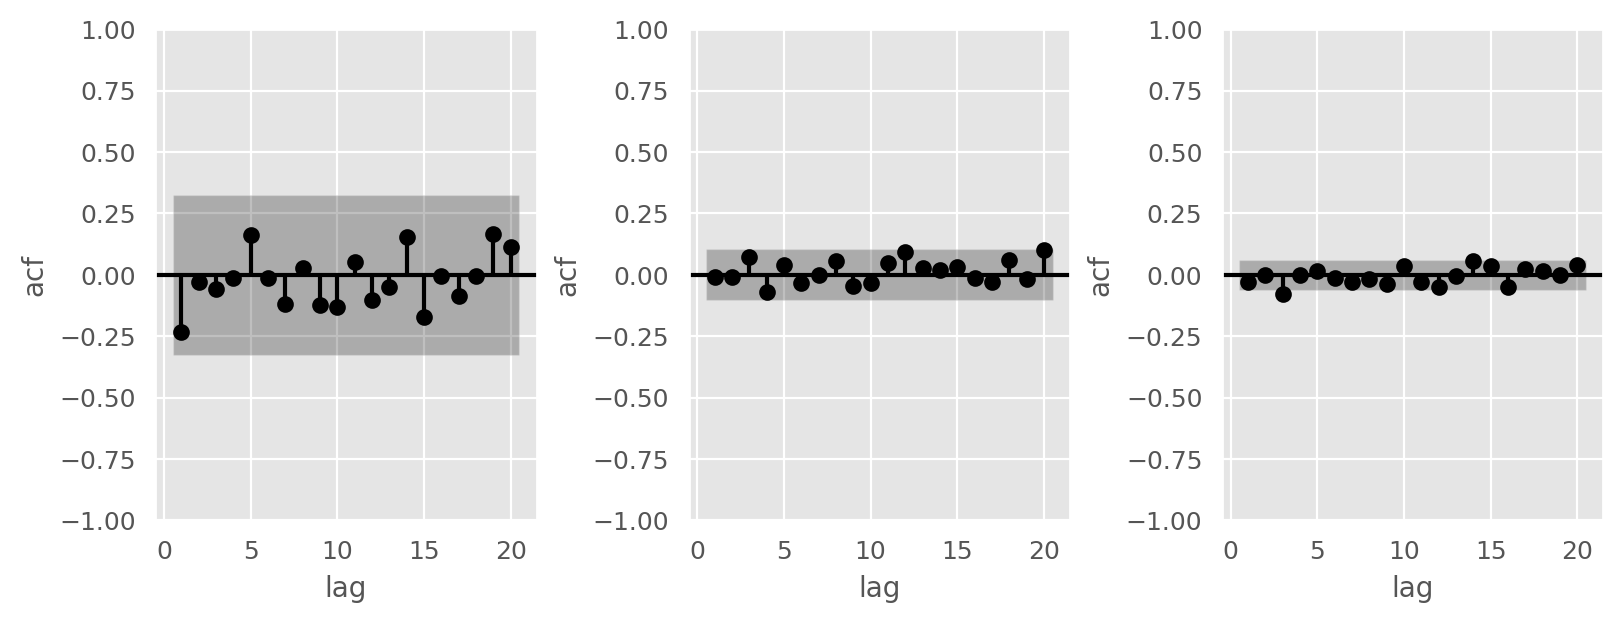
> Figure 9.32: Left: ACF for a white noise series of 36 numbers. Middle: ACF for a white noise series of 360 numbers. Right: ACF for a white noise series of 1,000 numbers.

a. There are some differences between ACF plots simply because I mention the ACF points are within $±1.96/\sqrt{T}$ where $T$ is the length of the time series. Thus, with different random numbers, we have a different gray shaded regions. 

The data are all white noise because they all lie within the gray shaded region. However, it is only just beyond the bounds.

b. The critical values are at different distances from the mean of zero because autocorrelations capture the linear relationship between lagged values of a time series. So, There are different autocorrelation coefficients.

#### 2. A classic example of a non-stationary series are stock prices. Plot the daily closing prices for Amazon stock (contained in `gafa_stock`), along with the ACF and PACF. Explain how each plot shows that the series is non-stationary and should be differenced.

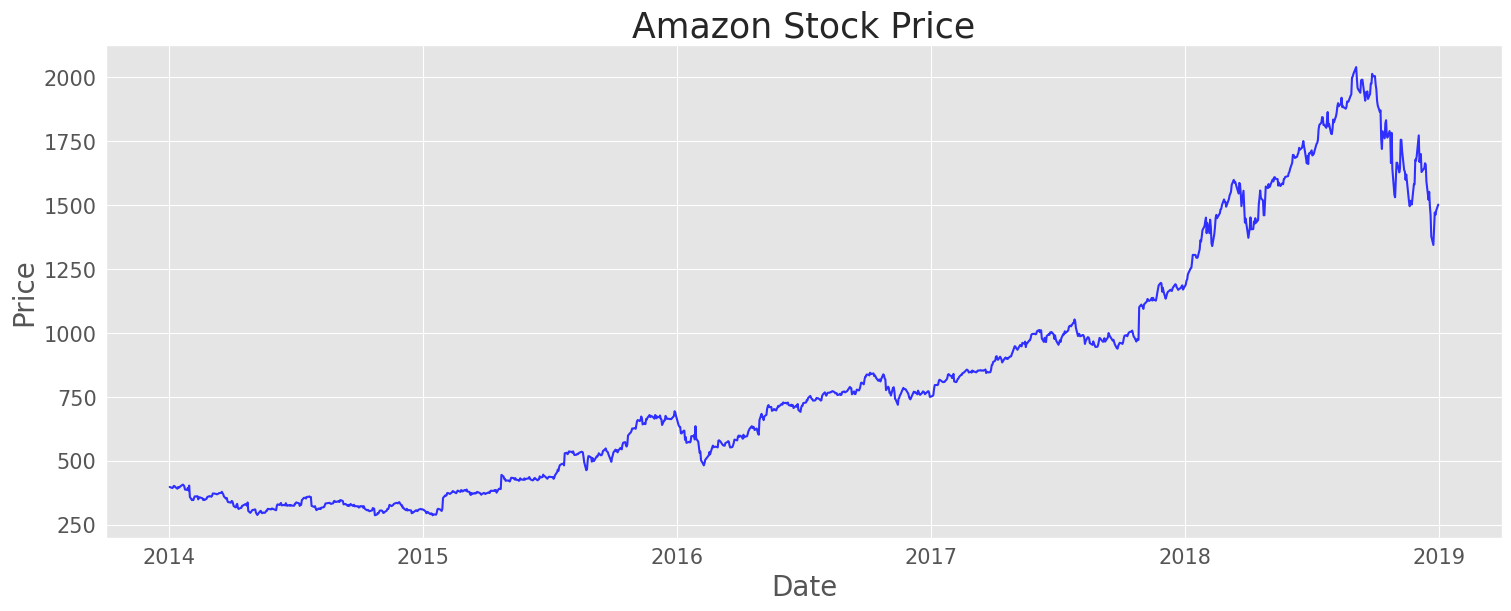

In [54]:
stock = (
    pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates=["ds"])
    .query("unique_id == 'AMZN_Close'")
    .reset_index(drop=True)
)

plot_series(stock, title="Amazon Stock Price", xlabel="Date", ylabel="Price")

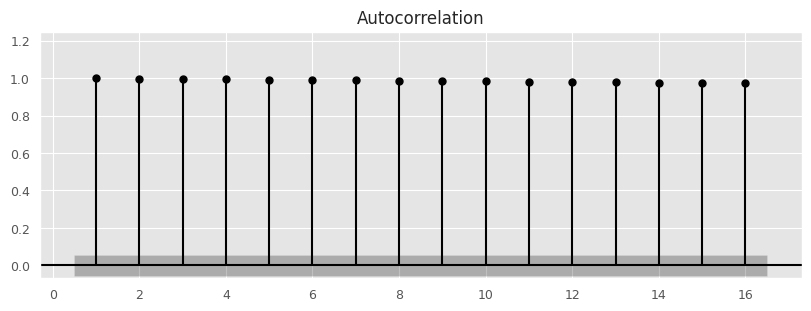

In [55]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_acf(
    stock["y"],
    lags=16,
    zero=False,
    bartlett_confint=False,
    auto_ylims=True,
    ax=ax
)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()



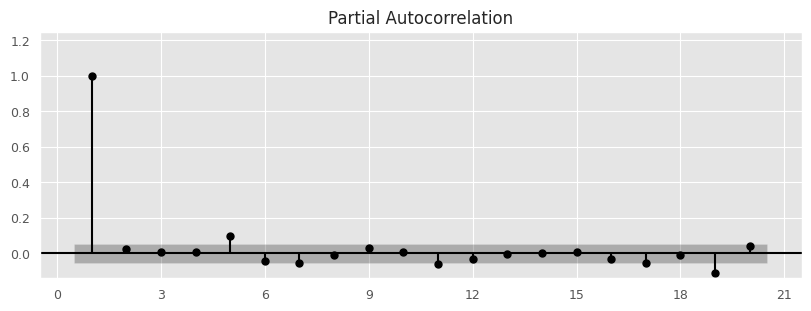

In [56]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_pacf(
    stock["y"],
    lags=20,
    zero=False,
    auto_ylims=True,
    ax=ax
)

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

In [57]:
ndiffs(stock["y"].to_numpy())

1

At time plot, we can see that the series has a upward trend and a strong seasonality. So, apperently, you should need to use Differencing to stablise the the mean of a time series by removing changes in the level of the time series.

Additionally, at the ACF plot, the autocorrelations decay slowly and remain large for many lags. This is a sign of non-stationary. 

Therefore, the series should be differenced before fitting an ARIMA model.

#### 3.For the following series, find an appropriate Box-Cox transformation and order of differencing in order to obtain stationary data.

a. Turkish GDP from `global_economy`.

b. Accommodation takings in the state of Tasmania from `aus_accommodation`.

c. Monthly sales from `souvenirs`.

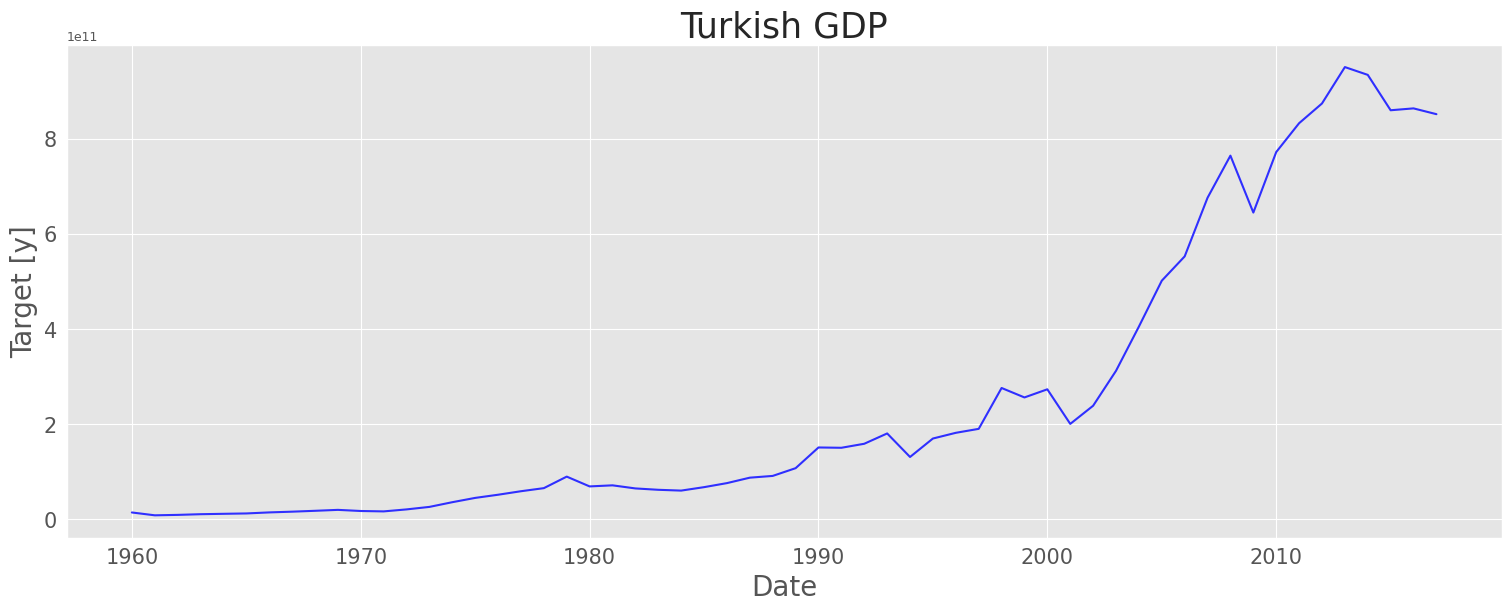

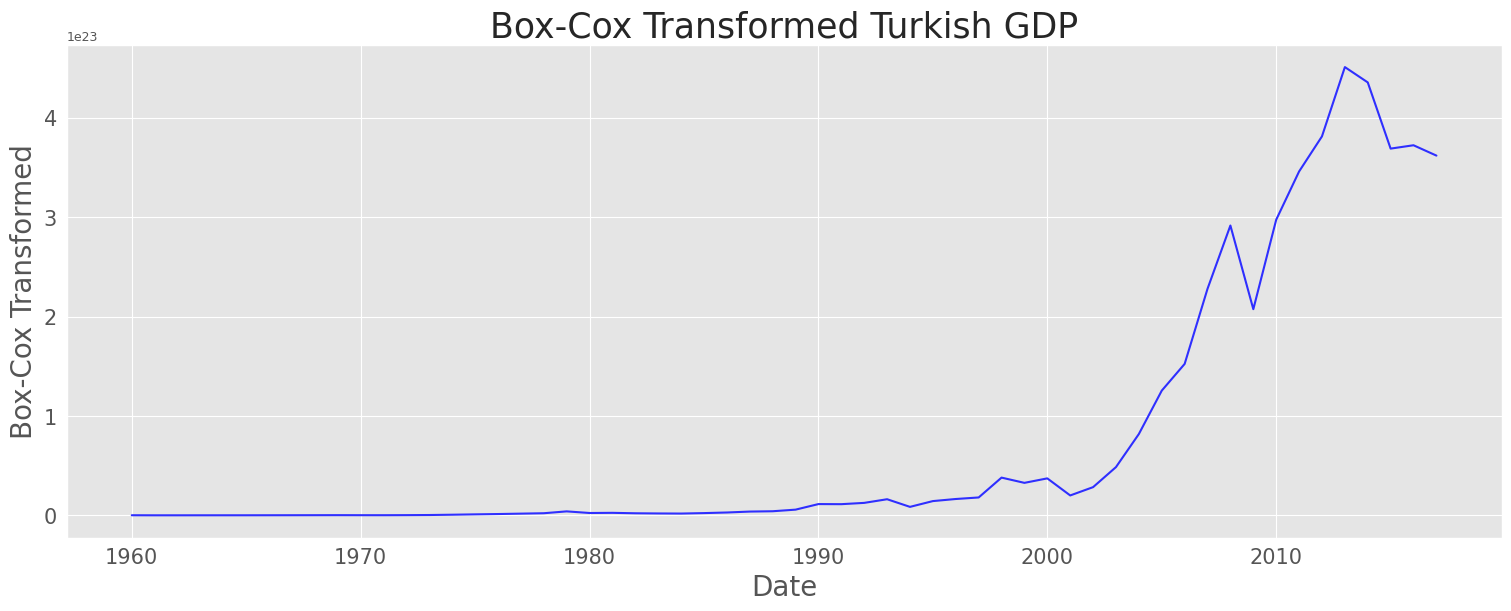

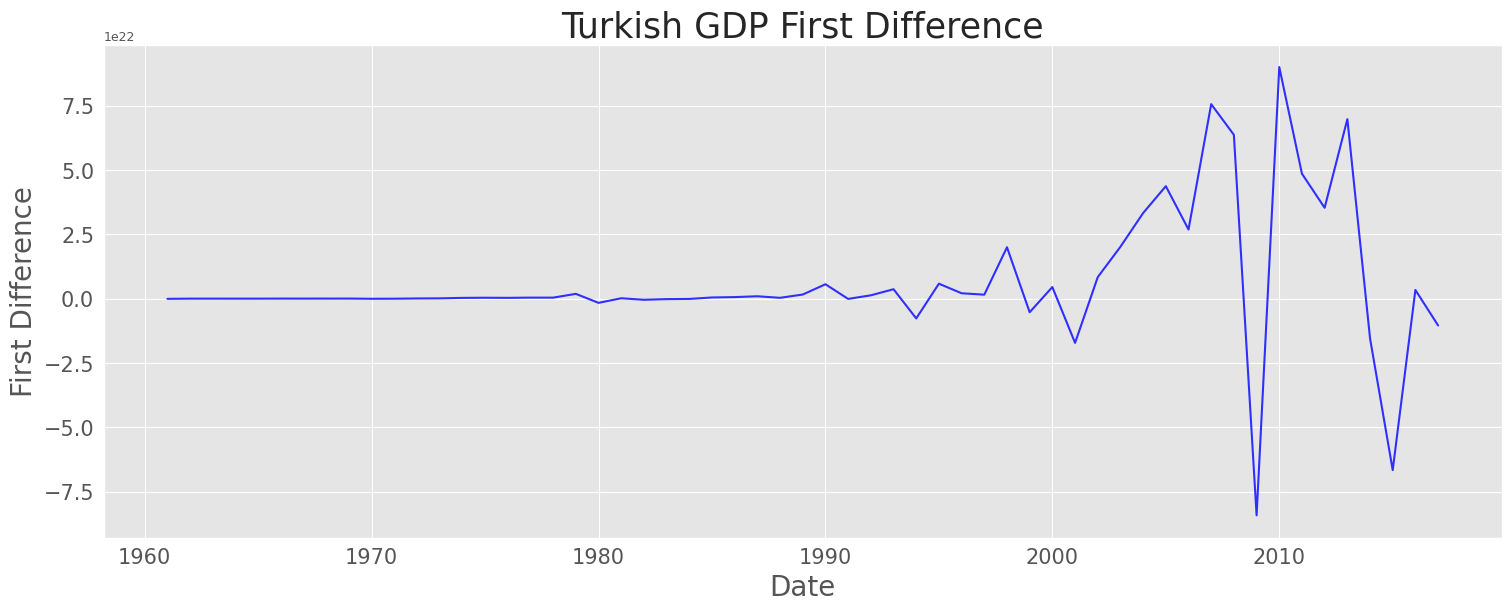

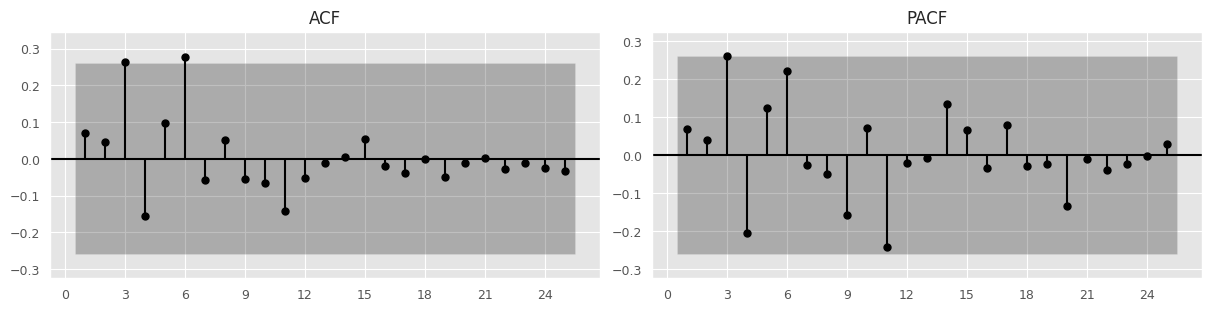

In [58]:
# a.
turkish_gpd = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates=["ds"])
    .query("unique_id == 'Turkey'")
    .rename(columns={"GDP": "y"})
    .reset_index(drop=True)
    [['unique_id', 'ds', 'y']]
)

def obtain_stationary_series(data: pd.DataFrame, season_length: Optional[int] = None, name: str = "Series") -> pd.DataFrame:
    fig = plot_series(data, title=name, xlabel="Date")
    display(fig)

    y = data["y"].to_numpy()
    optim_lambda = boxcox_lambda(y, method="guerrero", season_length=season_length)
    y_boxcox = boxcox(y, optim_lambda)

    transformed_df = pd.DataFrame({
        "unique_id": data["unique_id"],
        "ds": data["ds"],
        "y": y_boxcox
    })

    fig1 = plot_series(
        transformed_df, 
        title=f"Box-Cox Transformed {name}",
        xlabel="Date",
        ylabel="Box-Cox Transformed"
    )
    display(fig1)

    differenced_y = transformed_df["y"].diff().dropna()

    differenced_df = pd.DataFrame({
        "unique_id": data["unique_id"].iloc[1:].values,
        "ds": data["ds"].iloc[1:].values,
        "y": differenced_y.values
    })

    fig2 = plot_series(
        differenced_df,
        title=f"{name} First Difference",
        xlabel="Date",
        ylabel="First Difference"
    )
    display(fig2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    plot_acf(
        differenced_df["y"],
        ax=axes[0],
        lags=25,
        zero=False,
        bartlett_confint=False,
        auto_ylims=True
    )
    axes[0].set_title("ACF")

    plot_pacf(
        differenced_df["y"],
        ax=axes[1],
        lags=25,
        zero=False,
        auto_ylims=True
    )
    axes[1].set_title("PACF")

    for ax in axes:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))


    return differenced_df

stationary_turkish_gpd = obtain_stationary_series(turkish_gpd, name="Turkish GDP", season_length=1)


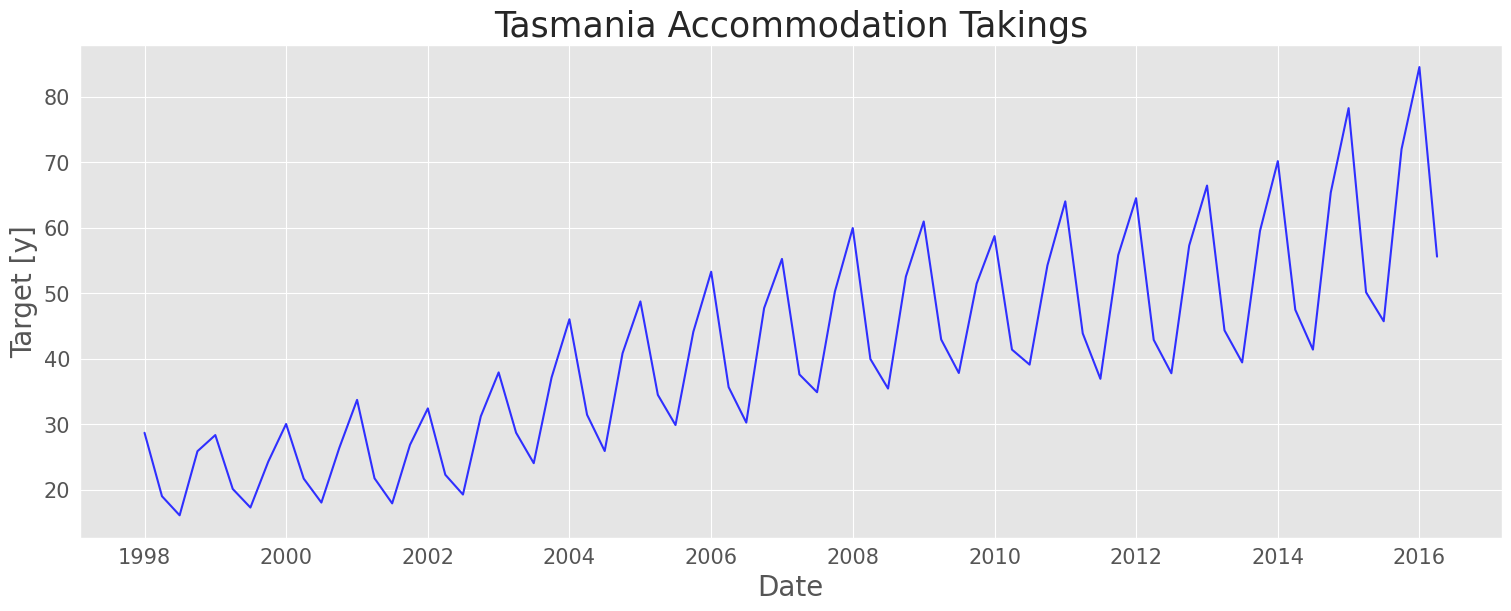

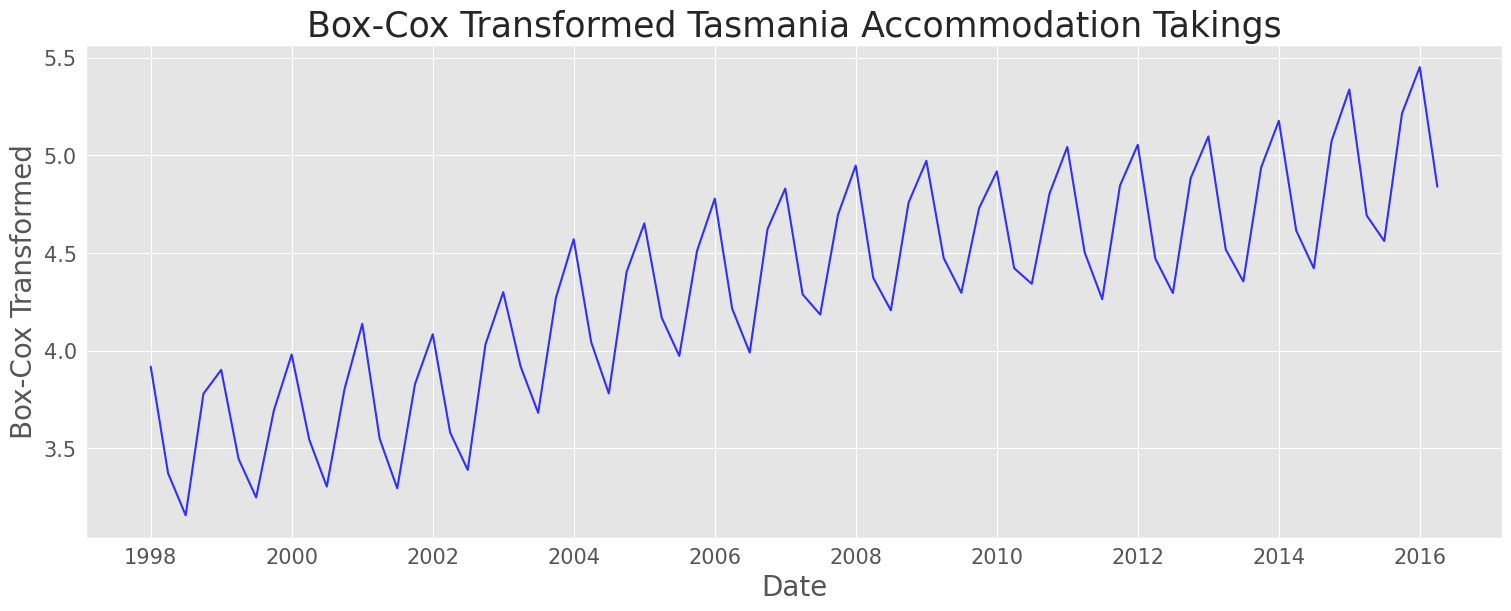

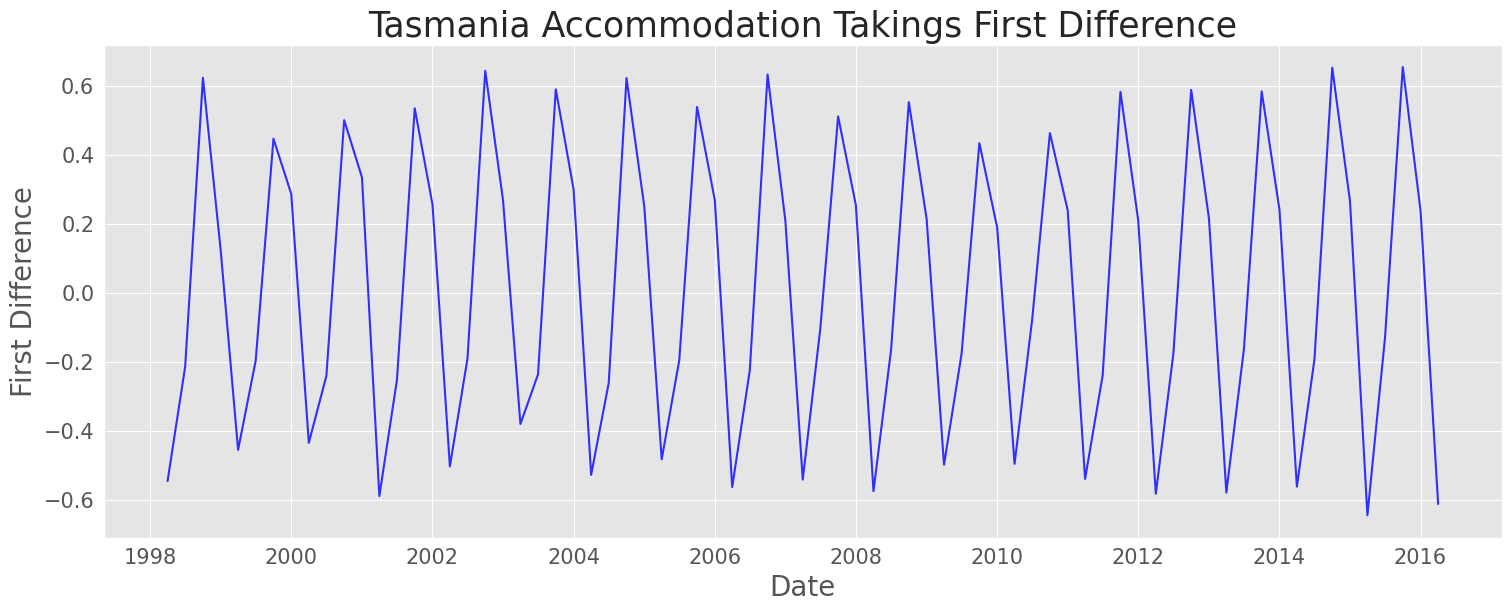

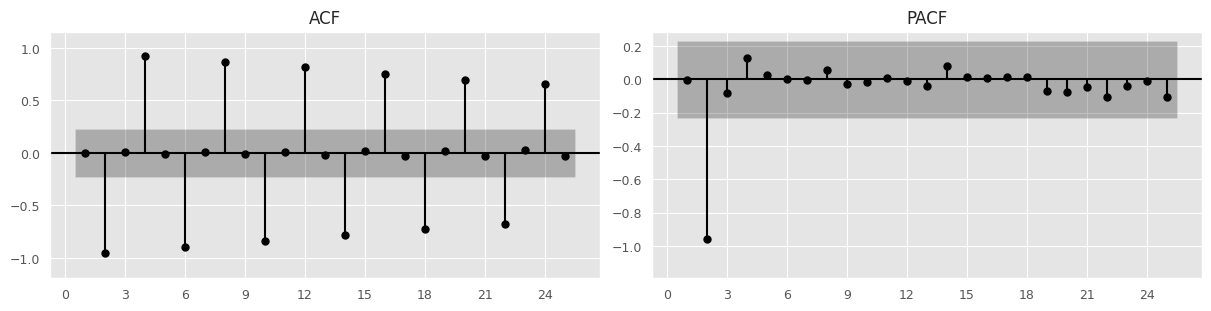

In [59]:
aus_accommodation = (
    pd.read_csv(DATA_DIR / "aus_accomodation.csv", parse_dates=["ds"])
    .query("unique_id == 'Tasmania'").reset_index(drop=True)
    .rename(columns={"Takings": "y"})
    [['unique_id', 'ds', 'y']]
)
aus_accommodation
stationary_aus_accommodation = obtain_stationary_series(aus_accommodation, season_length=12, name="Tasmania Accommodation Takings")

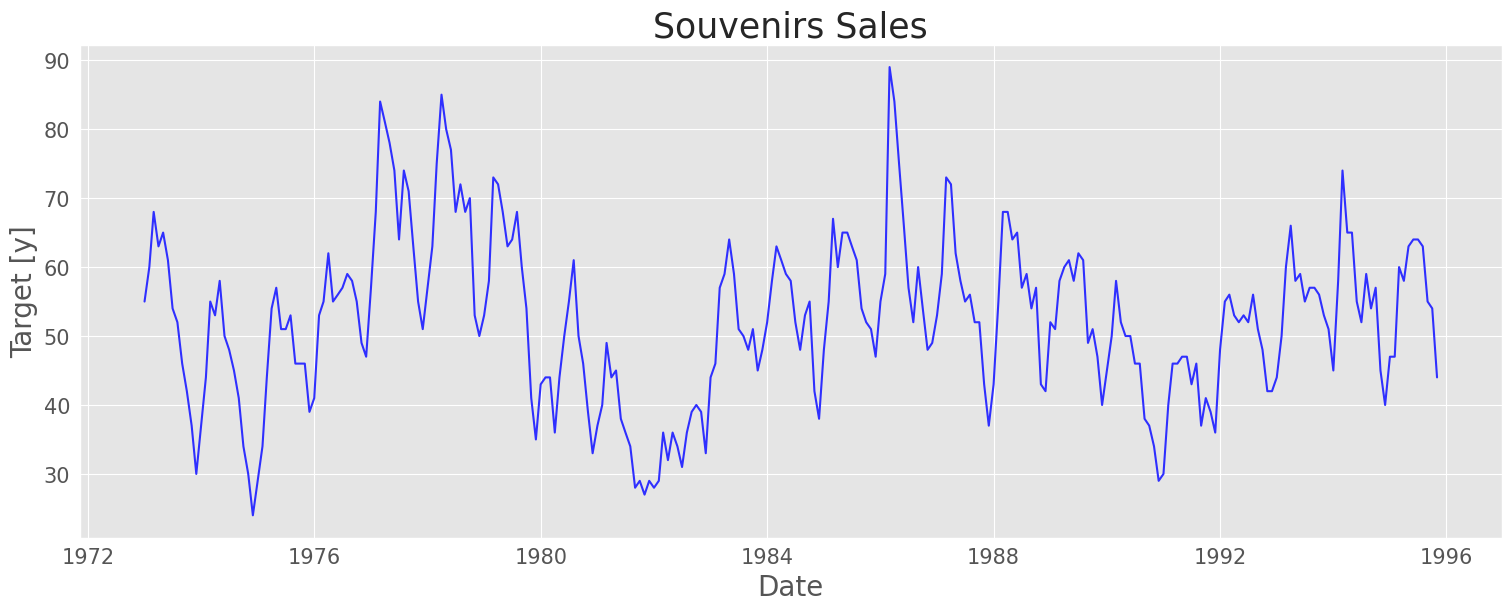

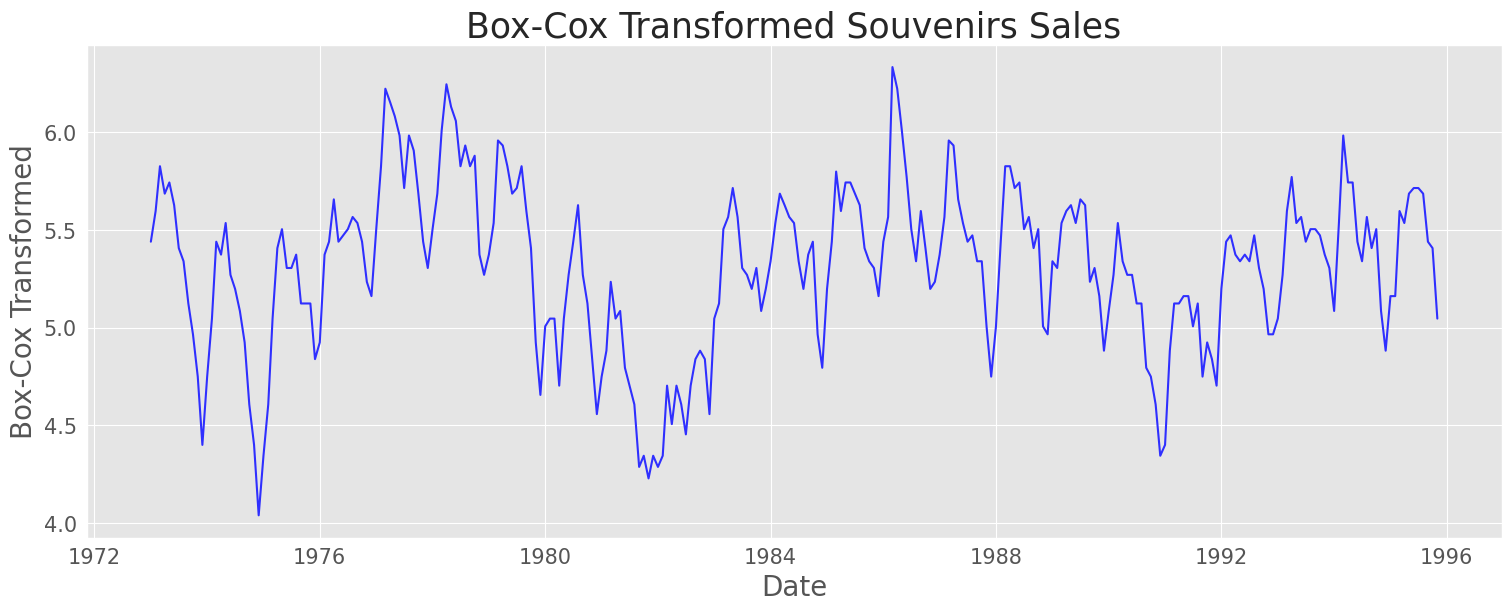

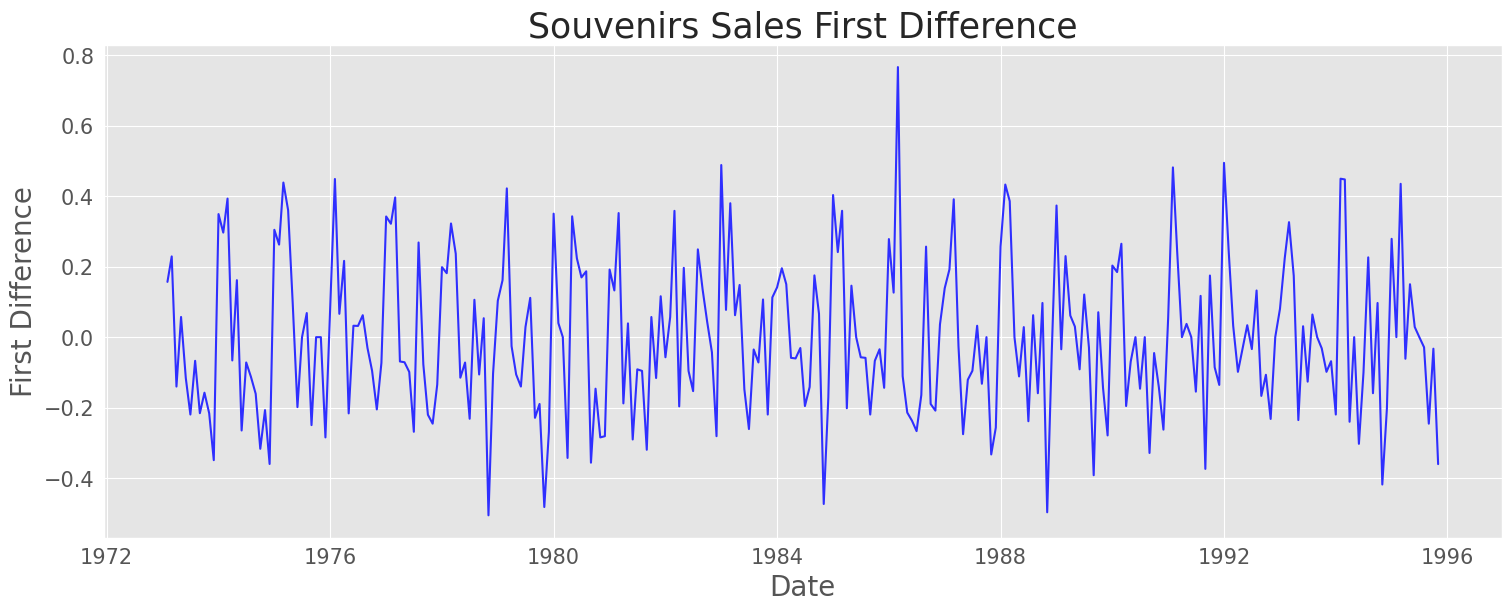

,unique_id,ds,y
0,Souvenirs,1973-02-01,0.157
1,Souvenirs,1973-03-01,0.229
2,Souvenirs,1973-04-01,-0.140
3,Souvenirs,1973-05-01,0.057
4,Souvenirs,1973-06-01,-0.116
...,...,...,...
269,Souvenirs,1995-07-01,0.000
270,Souvenirs,1995-08-01,-0.029
271,Souvenirs,1995-09-01,-0.246
272,Souvenirs,1995-10-01,-0.033


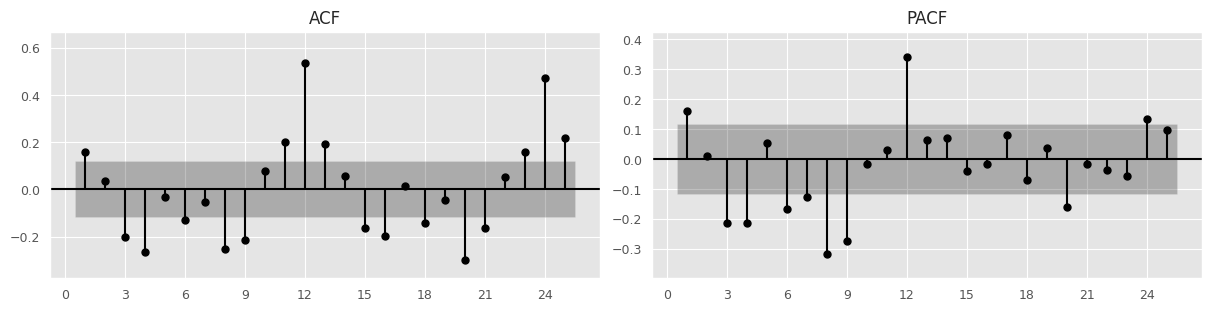

In [60]:
souvenirs = (
    pd.read_csv(DATA_DIR / "hsales.csv", parse_dates=["ds"])
    .assign(unique_id="Souvenirs")
)
obtain_stationary_series(souvenirs, name="Souvenirs Sales", season_length=12)

#### 4. For the `souvenirs` data, write down the differences you chose above using backshift operator notation.

$$(1-B)^dy_t$$

#### 5. For your retail data (from Exercise 7 in Section 2.10), find the appropriate order of differencing (after transformation if necessary) to obtain stationary data.

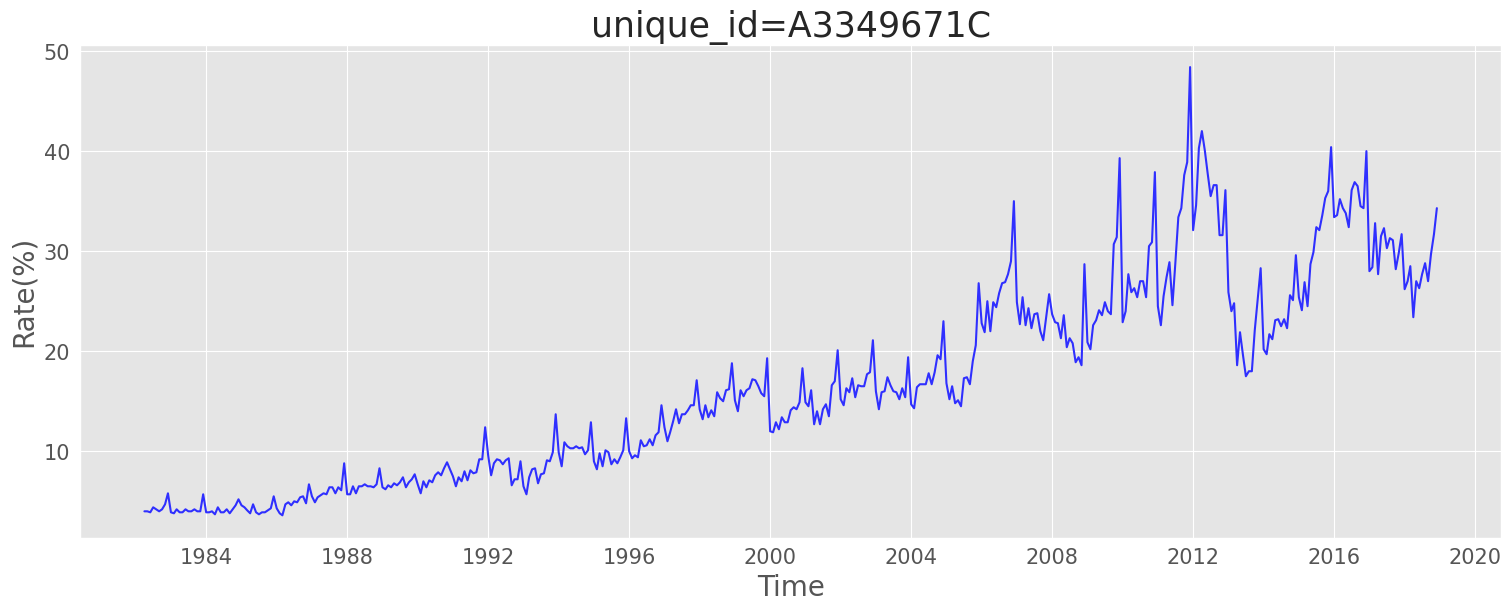

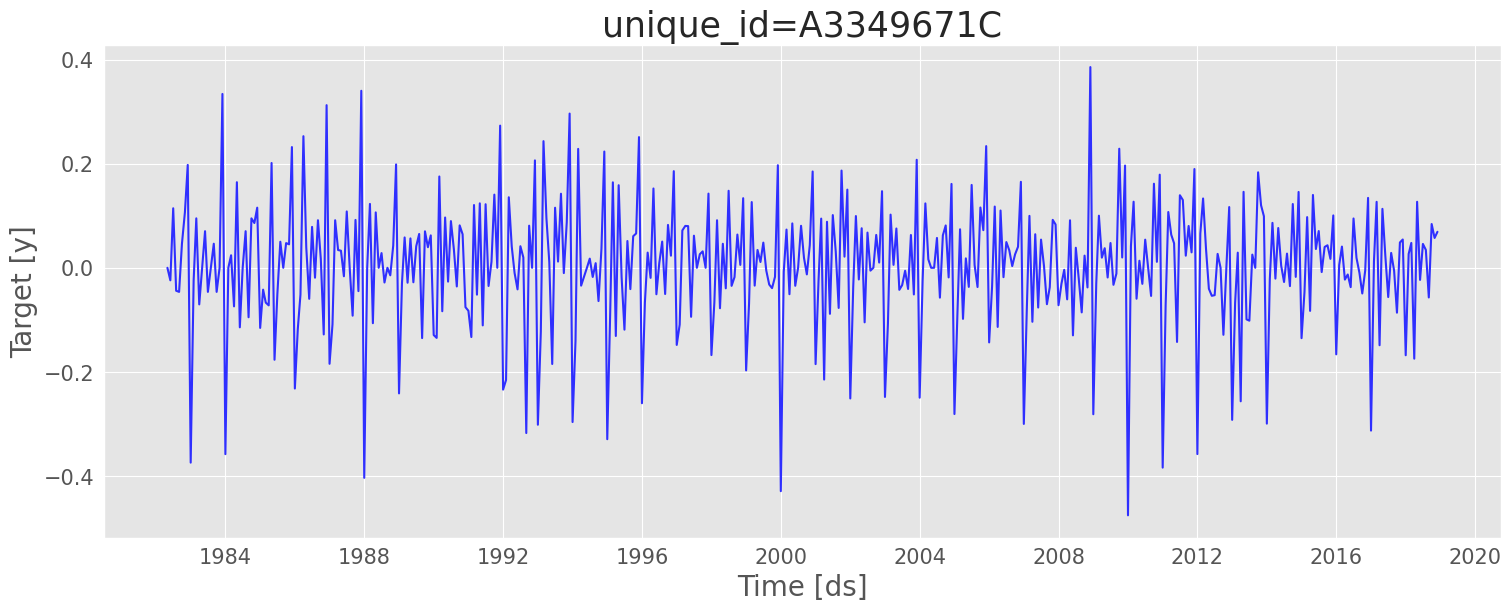

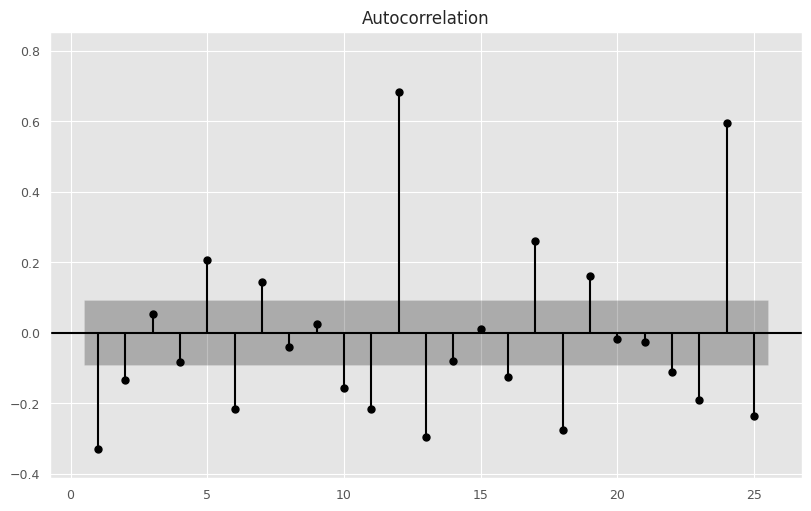

In [61]:
aus_retail = pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates = ['Month'])
aus_retail

random = np.random.RandomState(123)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]
myseries = myseries[["Series ID", "Month", "Turnover"]].rename(columns={"Turnover": "y", "Month": "ds", "Series ID": "unique_id"}).reset_index(drop=True)

# Time Series Plot
fig1 = plot_series(myseries, time_col = 'ds', id_col = 'unique_id', target_col = 'y')
for ax in fig1.axes:
    ax.set_ylabel("Rate(%)")
    ax.set_xlabel("Time")
display(fig1)

y = myseries["y"].to_numpy()
optim_lambda = boxcox_lambda(y, method="guerrero", season_length=12)
y_boxcox = boxcox(y, optim_lambda)

differenced_y = pd.Series(y_boxcox).diff().dropna()
# ddifferenced_y = pd.Series(y_boxcox).diff().diff().dropna()
differenced_df = pd.DataFrame({
    "unique_id": myseries["unique_id"].iloc[1:].values, # change to 1 if only first differencing, change to 2 if second differencing
    "ds": myseries["ds"].iloc[1:].values,
    "y": differenced_y.values
})

fig2 = plot_series(differenced_df, time_col = 'ds', id_col = 'unique_id', target_col = 'y')
display(fig2)

fig3 = plot_acf(
    differenced_y,
    lags=25,
    zero=False,
    bartlett_confint=False,
    auto_ylims=True
)

In [62]:
ndiffs(myseries["y"].to_numpy())

1

So, the answer is just **first-order differenced**.

if you differenced more than needed, the series becomes over-differenced.

what happens:
* Remove useful structure from the data, not just the trend.
* The series can become too "zig-zaggy" with strong negative autocorrelations at lag 1.
* Forecasts can become unstable or unnecessarily noisy.
* Prediction intervals may become wider than necessary.
* The fitted ARIMA model may need extra MA terms just to compensate for the over-differencing.
* You lose observations each time you difference. First differencing loses 1 row; second differencing loses 2 rows; seasonal differencing loses m rows.

#### 6. Simulate and plot some data from simple ARIMA models.

a. Use the following Python code to generate data from an AR(1) model with $\phi_1 = 0.6$ and $\sigma^2 = 1$. The process starts with $y_1 = 0$

```
y = np.zeros(100)
e = np.random.normal(size=100)
for i in range(1, 100):
  y[i] = 0.6 * y[i-1] + e[i]
sim = pd.DataFrame({"y": y})
```
b. Produce a time plot for the series. How does the plot change as you change $\phi_1$?

c. Write your own code to generate data from an MA(1) model with $\theta_1 = 0.6$ and $\sigma^2 = 1$

d. Produce a time plot for the series. How does the plot change as you change $\theta_1$

e. Generate data from an ARMA(1,1) model with $\phi_1 = 0.6$ and $\sigma^2 = 1$.

f. Generate data from an AR(2) model with $\phi_1 = -0.8, \phi_2 = 0.3$ and $\sigma^2=1$. (Note that these parameters will give a non-stationary series.)

g. Graph the latter two series and compare them.

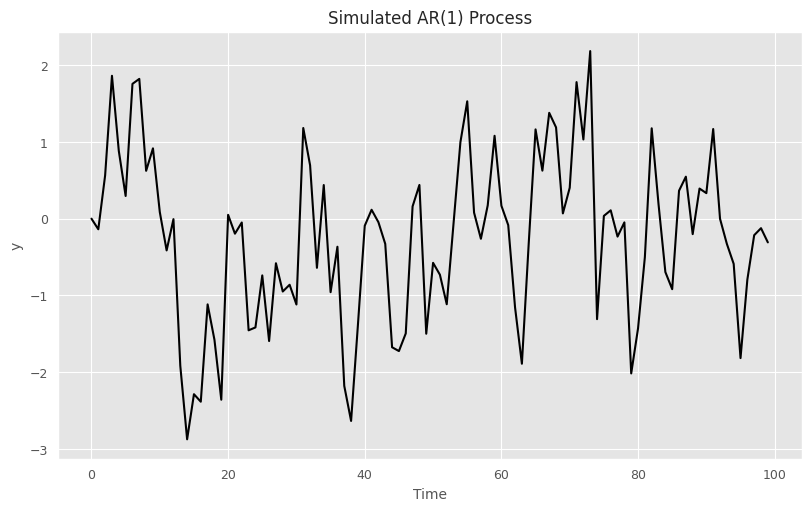

In [63]:
# b
np.random.seed(42)

y = np.zeros(100)
e = np.random.normal(size=100)

for i in range(1, 100):
    y[i] = 0.6 * y[i-1] + e[i]

sim = pd.DataFrame({"y": y})

sns.lineplot(data=sim, y="y", x=sim.index)
plt.title("Simulated AR(1) Process")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()

# when I changes Phi values, the series will be more or less stationary. 
# If the Phi value is closer to 1, the series will be less stationary, and if it is closer to 0, the series will be more stationary.

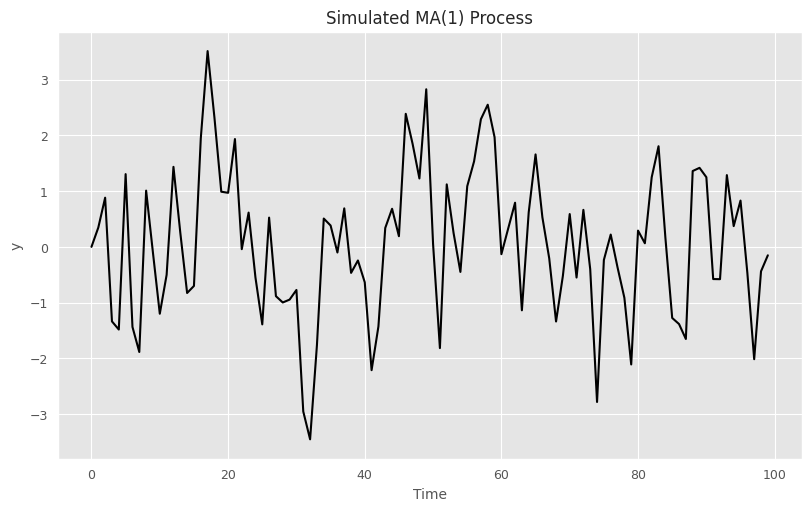

In [64]:
# c. 
np.random.seed(123)

n = 100
theta1 = 0.6
sigma = 1

e = np.random.normal(loc=0, scale=sigma, size=n)
y = np.zeros(n)

for t in range(1, n):
    y[t] = e[t] + theta1 * e[t-1]

sim_ma1 = pd.DataFrame({"y": y})

sns.lineplot(data=sim_ma1, x=sim_ma1.index, y="y")
plt.title("Simulated MA(1) Process")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()

# Changing theta changes the short-term autocorrelation of the MA(1) series.
# If theta is close to 0, the series behaves more like white noise.
# If theta has a larger magnitude, consecutive values are more strongly correlated.
# However, an MA(1) process is stationary for any finite theta value.

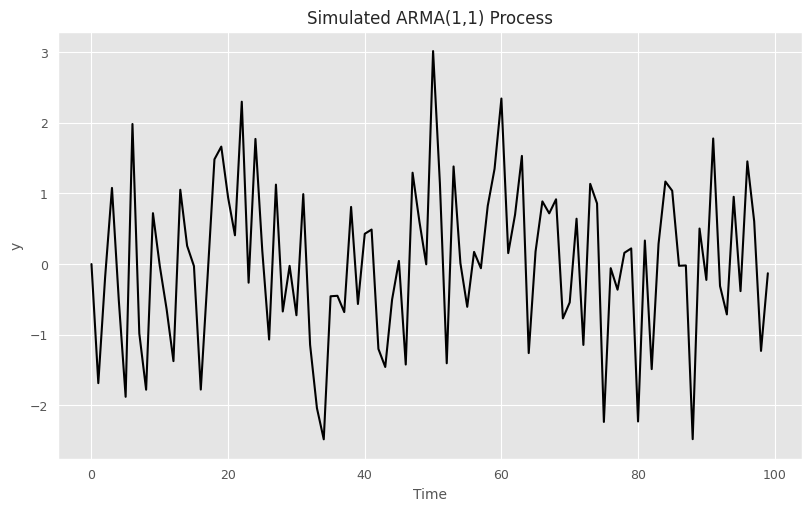

In [65]:
np.random.seed(123)
phi_1 = 0.6 
theta_1 = 0.6
sigma = 1
n = 100

e = np.random.normal(loc=0, scale=sigma, size=n)
y = np.zeros(n)
for t in range(1, n):
    y[t] = phi_1 * y[t-1] +  e[t-1] - theta_1 * e[t]

sim_arma11 = pd.DataFrame({"time": range(n), "y": y})

sns.lineplot(data=sim_arma11, x="time", y="y")
plt.title("Simulated ARMA(1,1) Process")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()

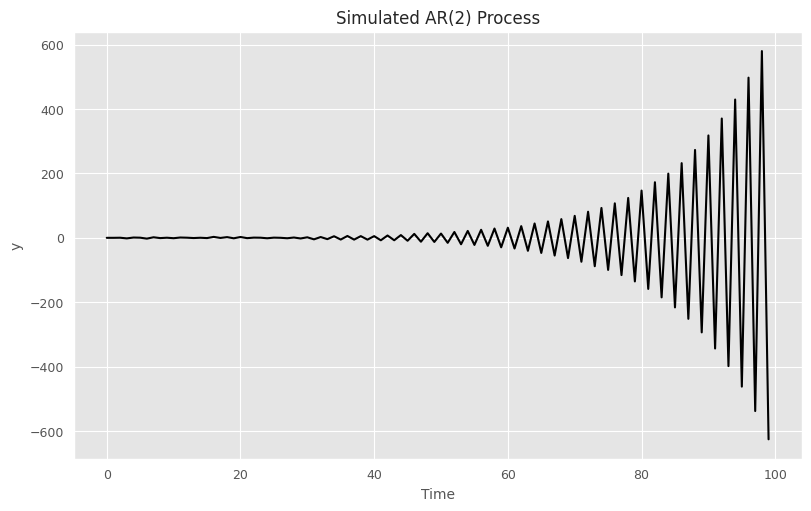

In [66]:
#  $\phi_1 = -0.8, \phi_2 = 0.3$ and $\sigma^2=1$.
np.random.seed(123)

phi_1 = -0.8
phi_2 = 0.3
sigma = 1
n = 100

e = np.random.normal(loc=0, scale=sigma, size=n)
y = np.zeros(n)
for t in range(2, n):
    y[t] = phi_1 * y[t-1] + phi_2 * y[t-2] + e[t]

sim_ar2 = pd.DataFrame({"time": range(n), "y": y})

sns.lineplot(data=sim_ar2, x="time", y="y")
plt.title("Simulated AR(2) Process")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()

#### 7. Consider `aus_airpassengers`, the total number of passengers (in millions) from Australian air carriers for the period 1970–2011.

a. Use `AutoARIMA()` to find an appropriate ARIMA model. What model was selected. Check that the residuals look like white noise. Plot forecasts for the next 10 periods.

b. Write the model in terms of the backshift operator.

c. Plot forecasts from an ARIMA(0,1,0) model with drift and compare these to part a.

d. Plot forecasts from an ARIMA(2,1,2) model with drift and compare these to parts a and c. Remove the constant and see what happens.

e. Plot forecasts from an ARIMA(0,2,1) model with a constant. What happens?


In [67]:
def plot_diagnostics(data):
    fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])

    ax = axes["resid"]
    ax.plot(data["ds"], data["resid"])
    ax.set(title="Innovation Residuals")

    ax = axes["acf"]
    plot_acf(
        data["resid"].dropna(),
        zero=False,
        bartlett_confint=False,
        auto_ylims=True,
        ax=ax,
    )
    ax.set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")

    ax = axes["hist"]
    ax.hist(data["resid"].dropna(), bins=20)
    ax.set(title="Histogram", xlabel="resid", ylabel="count")

    return fig

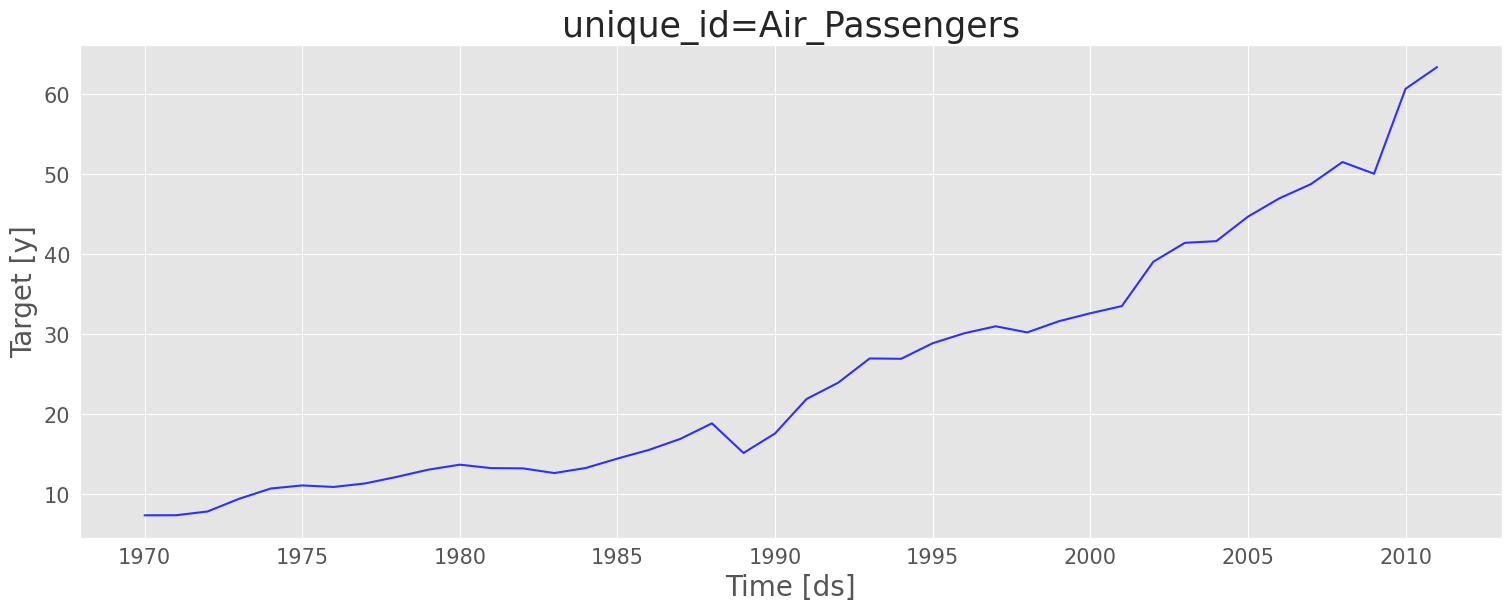

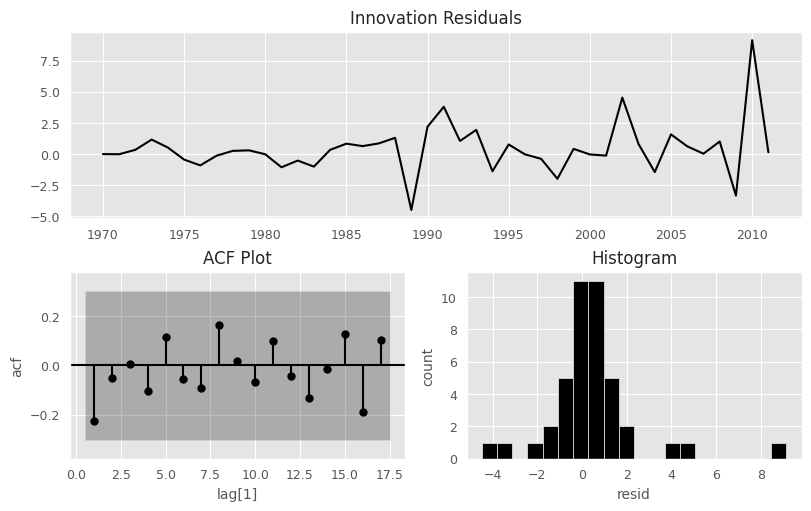

In [68]:
aus_airpassengers = (
    pd.read_csv(DATA_DIR / "aus_airpassengers.csv", parse_dates=["Year"])
    .assign(unique_id="Air_Passengers")
    .rename(columns={"Year": "ds", "Passengers": "y"})
    .drop(columns=["Unnamed: 0"], inplace=False)
    .loc[:41, ["ds", "y", "unique_id"]]
)

fig = plot_series(aus_airpassengers, time_col="ds", id_col="unique_id", target_col="y")
display(fig)

sf = StatsForecast(
    models=[AutoARIMA(alias="AutoARIMA", seasonal=False, stepwise=True)],
    freq="Y",
    n_jobs=1
)

forecast = sf.forecast(
    h=10,
    df=aus_airpassengers,
    fitted=True
)

residuals = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["AutoARIMA"]
)
fig3 = plot_diagnostics(residuals)
# fitted_values = sf.forecast_fitted_values()
# evaluation = evaluate(fitted_values, metrics=[rmse, mae], models = ['AutoARIMA'])
# display(evaluation)


In [69]:
sf.fit(df=aus_airpassengers)

model = sf.fitted_[0, 0].model_

p, q, P, Q, m, d, D = model["arma"]
coefs = dict(model["coef"])

print(f"Selected model: ARIMA({p}, {d}, {q})")
print("Coefficients:", coefs)
print("Sigma^2:", model["sigma2"])
print("AICc:", model["aicc"])

Selected model: ARIMA(0, 2, 1)
Coefficients: {'ma1': np.float64(-0.8795160069352991)}
Sigma^2: 4.667548854622027
AICc: 179.93722714531233


the model in terms of the backshift operator with $\theta_1 \approx -0.8795$, $\epsilon_t$ is white noise with $\sigma \approx \sqrt{4.6675}$: 
$$(1-B)^2 y_t = c + (1-\theta_1 B)\epsilon_t$$

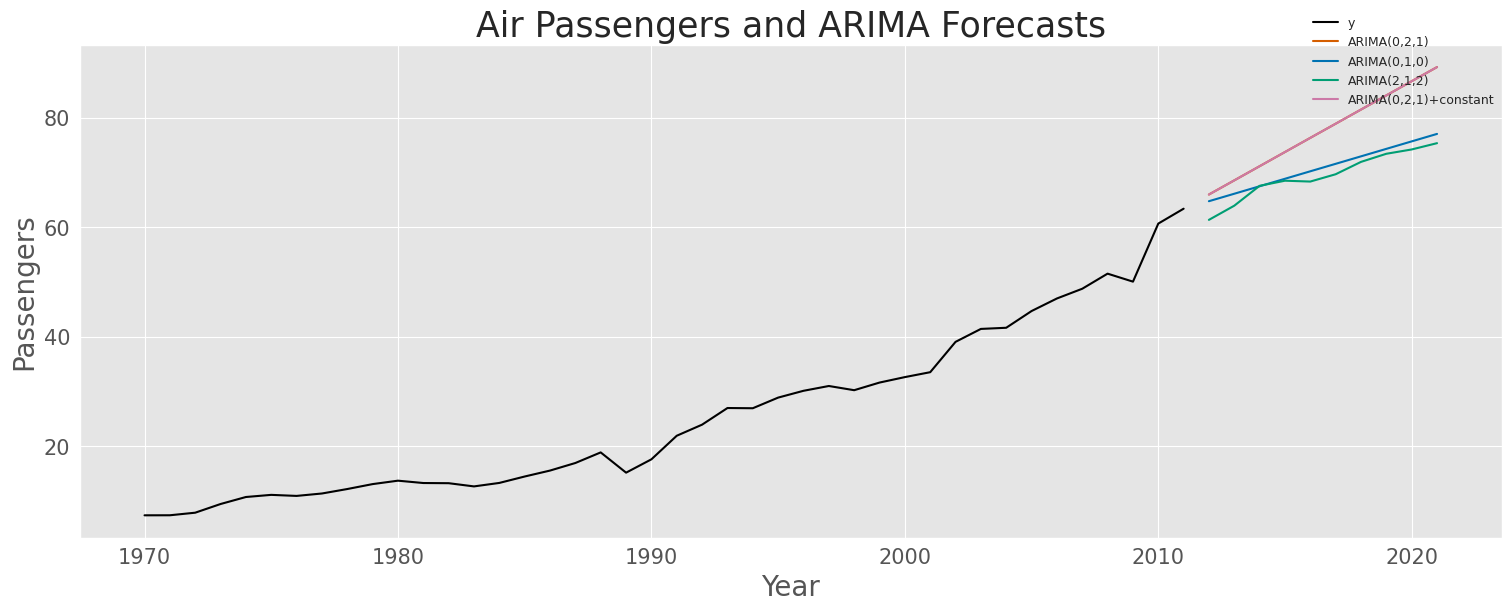

In [70]:
models = [ARIMA([0,2,1], alias = "ARIMA(0,2,1)"), 
          ARIMA([0,1,0], include_drift=True, alias = "ARIMA(0,1,0)"), 
          ARIMA([2,1,2], include_drift=True, alias = "ARIMA(2,1,2)"), 
          ARIMA([0,2,1], include_constant=True,include_mean = True, alias = "ARIMA(0,2,1)+constant")]

sf = StatsForecast(models=models, freq="Y", n_jobs=1)
forecasts = sf.forecast(h=10, df=aus_airpassengers, fitted=True)

fig = plot_series(aus_airpassengers, forecasts, title="Air Passengers and ARIMA Forecasts", xlabel="Year", ylabel="Passengers", 
                  palette = "black_and_4color", rm_legend=False)
display(fig)

In [71]:
sf.fit(df=aus_airpassengers)

rows = []

for i, model_name in enumerate([m.alias for m in models]):
    fitted_model = sf.fitted_[0, i].model_

    p, q, P, Q, m, d, D = fitted_model["arma"]

    rows.append({
        "Alias": model_name,
        "Model": f"ARIMA({p},{d},{q})",
        "sigma2": fitted_model["sigma2"],
        "AIC": fitted_model["aic"],
        "AICc": fitted_model["aicc"],
        "BIC": fitted_model["bic"],
        "coefficients": fitted_model["coef"]
    })

aicc_table = pd.DataFrame(rows).sort_values("AICc")

aicc_table

,Alias,Model,sigma2,AIC,AICc,BIC,coefficients
0,"ARIMA(0,2,1)","ARIMA(0,2,1)",4.668,179.613,179.937,182.991,{'ma1': -0.8795160069352991}
3,"ARIMA(0,2,1)+constant","ARIMA(0,2,1)",4.668,179.613,179.937,182.991,{'ma1': -0.8795160069352991}
1,"ARIMA(0,1,0)","ARIMA(0,1,0)",4.629,182.165,182.481,185.592,{'drift': 1.3668685448243905}
2,"ARIMA(2,1,2)","ARIMA(2,1,2)",2.316,198.326,200.797,208.608,"{'ar1': 0.16444504460116258, 'ar2': -0.6193381295719074, 'ma1': -1.045371159236427, 'ma2': 1.631..."


c. Plot forecasts from an ARIMA(0,1,0) model with drift and compare these to part a.
- ARIMA(0,1,0) has lower AICc than ARIMA(0,2,1)

d. Plot forecasts from an ARIMA(2,1,2) model with drift and compare these to parts a and c. Remove the constant and see what happens.
- ARIMA(2,1,2) has lower AICc than ARIMA(0,2,1) and ARIMA(0,1,0). When I remove the constant, the forecast would be worse than the forecast with the constant and become a traight line. 

e. Plot forecasts from an ARIMA(0,2,1) model with a constant. What happens?
- the same with ARIMA(0,2,1)

#### 8. For the United States GDP series (from `global_economy`):

a. If necessary, find a suitable Box-Cox transformation for the data;

b. Fit a suitable ARIMA model to the transformed data using `AutoARIMA()`;

c. Try some other plausible models by experimenting with the orders chosen;

d. Choose what you think is the best model and check the residual diagnostics;

e. Produce forecasts of your fitted model. Do the forecasts look reasonable?

f. Compare the results with what you would obtain using `AutoETS()` (with no transformation).

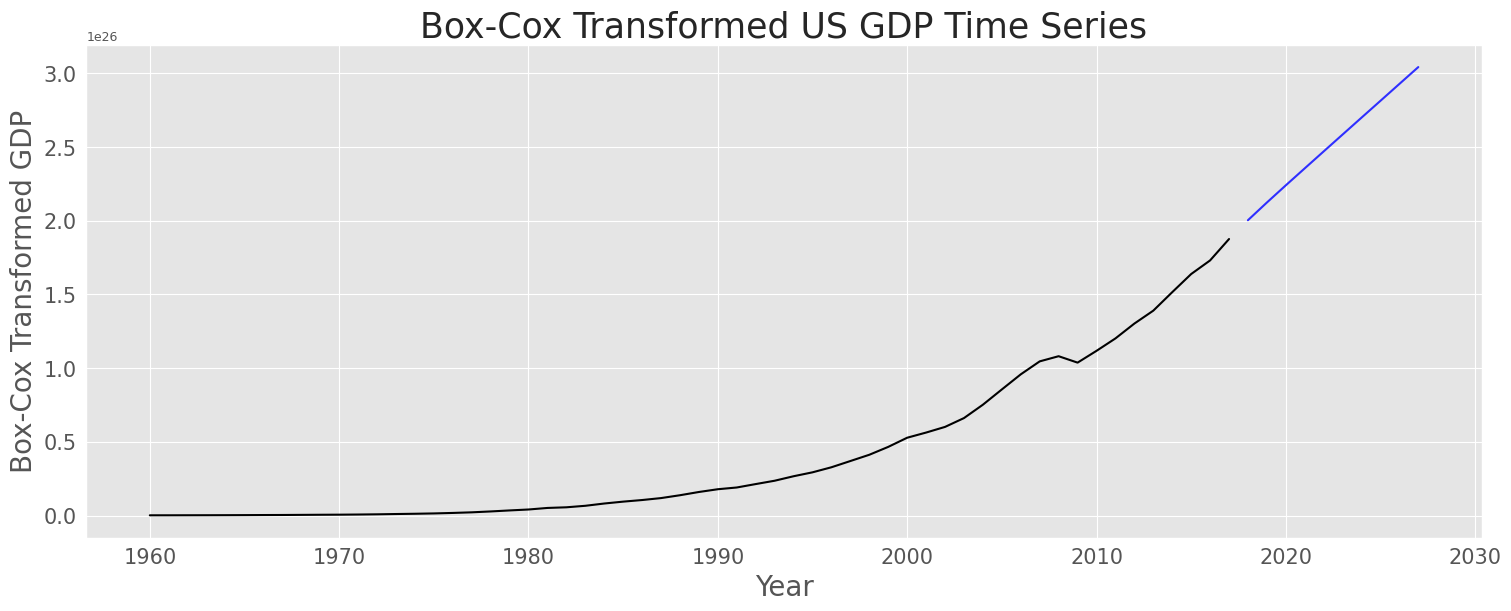

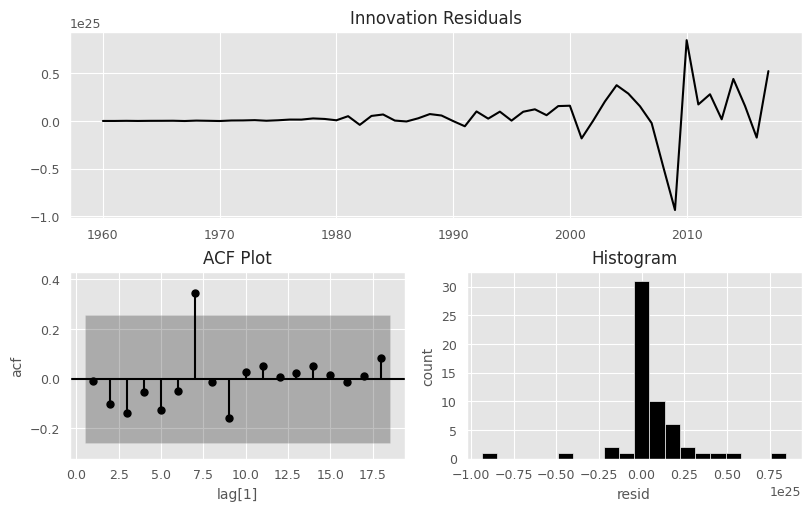

In [72]:
global_economy = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates=["ds"])
    .query("unique_id == 'United States'")
    .rename(columns={"GDP": "y"})
    .reset_index(drop=True)
    [["y", "ds", "unique_id"]]
                  )

# plot_series(global_economy, time_col="ds", id_col="unique_id", target_col="y", title="US GDP Time Series", xlabel="Year", ylabel="GDP")

y = global_economy["y"].to_numpy()
optim_lambda = boxcox_lambda(y, method="guerrero", season_length=1)
y_transformed = boxcox(y, optim_lambda)

transformed_df = pd.DataFrame({
    "unique_id": global_economy["unique_id"],
    "ds": global_economy["ds"],
    "y": y_transformed
})

# fig = plot_series(transformed_df, time_col="ds", id_col="unique_id", target_col="y", title="Box-Cox Transformed US GDP Time Series", xlabel="Year", ylabel="Box-Cox Transformed GDP")
# display(fig)

sf = StatsForecast(
    models=[AutoARIMA(alias="AutoARIMA", seasonal=False, stepwise=True)],
    freq="Y",
    n_jobs=1
)
forecast = sf.forecast(
    h=10,
    df=transformed_df,
    fitted=True
)
residuals = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["AutoARIMA"]
)
fig3 = plot_diagnostics(residuals)
fig = plot_series(transformed_df, forecast, time_col="ds", id_col="unique_id", target_col="y", title="Box-Cox Transformed US GDP Time Series", xlabel="Year", ylabel="Box-Cox Transformed GDP")
display(fig)

#### 9. Consider `aus_arrivals`, the quarterly number of international visitors to Australia from several countries for the period 1981 Q1 – 2012 Q3.

a. Select one country and describe the time plot.

b. Use differencing to obtain stationary data.

c. What can you learn from the ACF graph of the differenced data?

d. What can you learn from the PACF graph of the differenced data?

e. What model do these graphs suggest?

f. Does AutoARIMA() give the same model that you chose? If not, which model do you think is better?

g. Write the model in terms of the backshift operator, then without using the backshift operator.

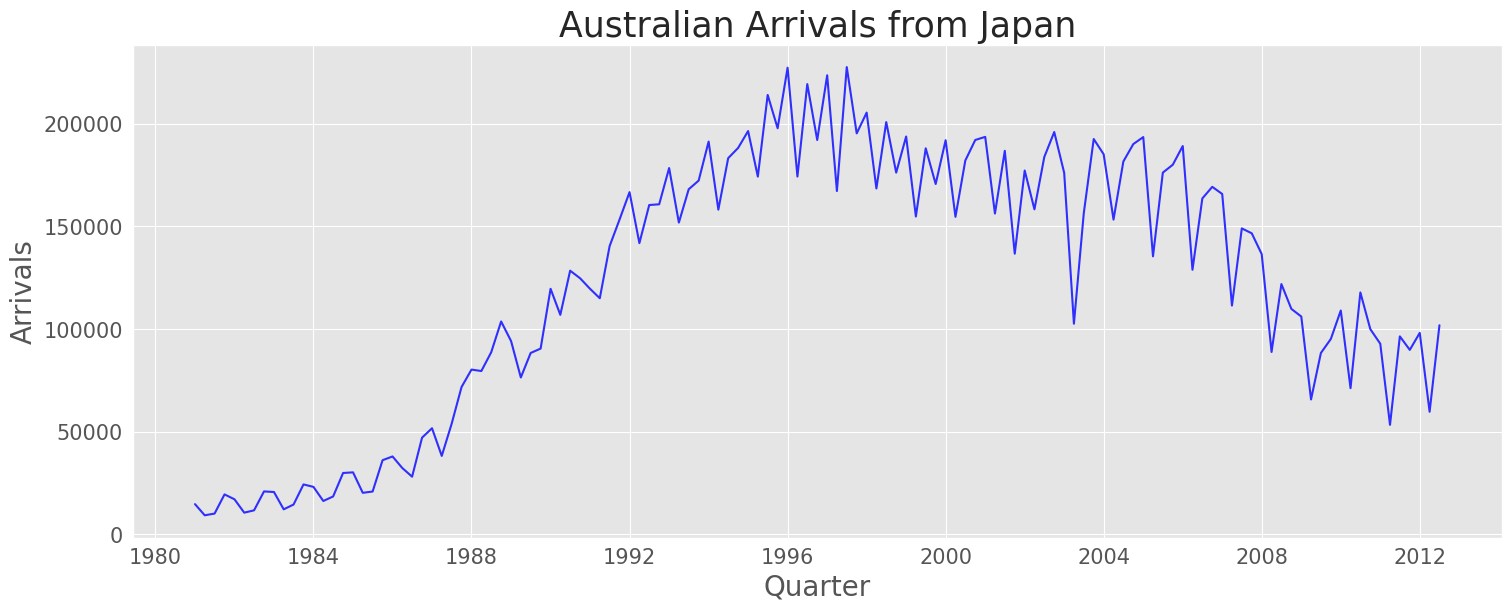

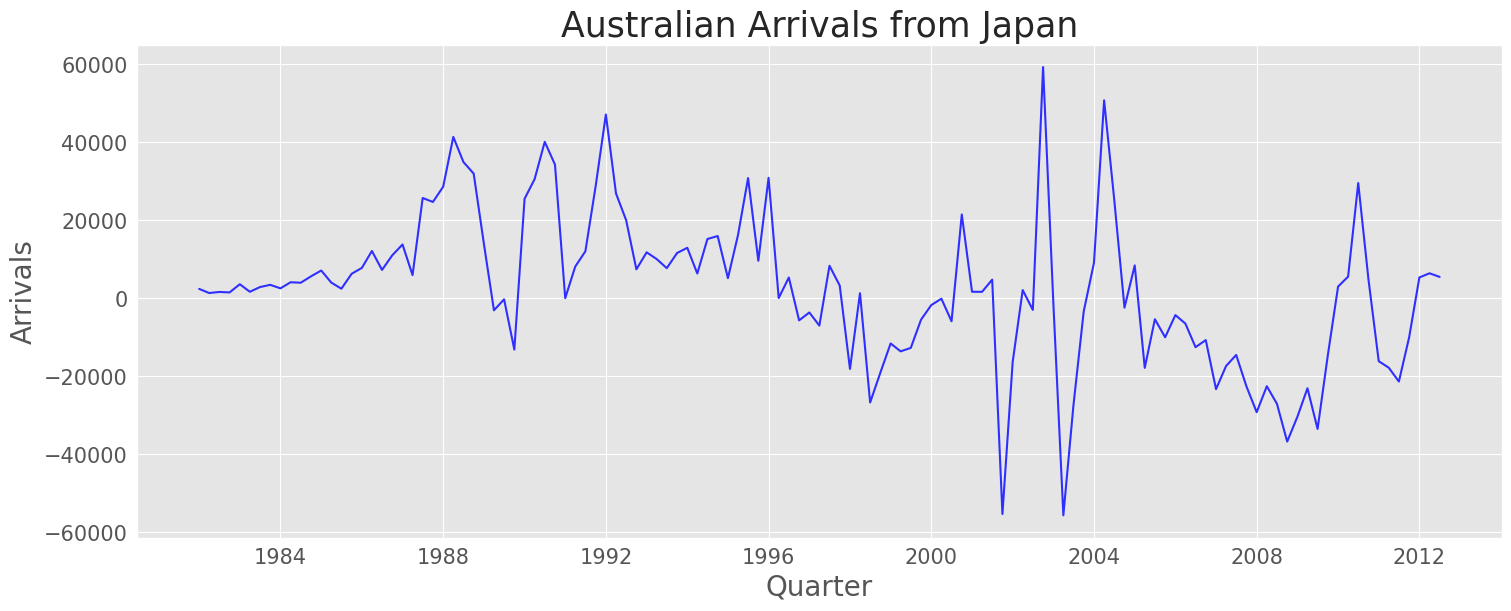

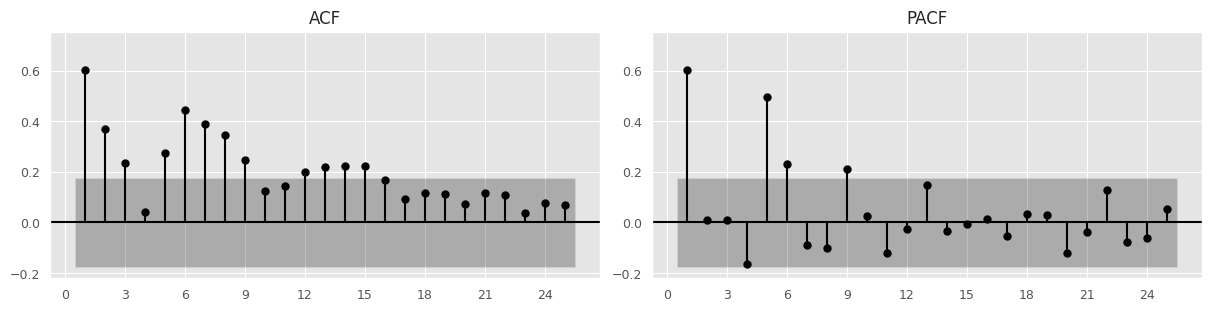

In [73]:
aus_arrivals = (
    pd.read_csv(DATA_DIR / "aus_arrivals.csv", parse_dates=["Quarter"])
    .query("Origin == 'Japan'") 
    .rename(columns={"Quarter": "ds", "Arrivals": "y", "Origin": "unique_id"})
                )
fig = plot_series(aus_arrivals, time_col="ds", id_col="unique_id", target_col="y", title="Australian Arrivals from Japan", xlabel="Quarter", ylabel="Arrivals")
display(fig)

differenced_y = aus_arrivals["y"].diff(4).dropna()
differenced_df = pd.DataFrame({
    "unique_id": aus_arrivals["unique_id"].iloc[4:].values,
    "ds": aus_arrivals["ds"].iloc[4:].values,
    "y": differenced_y.values
})

fig1 = plot_series(differenced_df, time_col="ds", id_col="unique_id", target_col="y", title="Australian Arrivals from Japan", xlabel="Quarter", ylabel="Arrivals")
display(fig1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

plot_acf(
        differenced_df["y"],
        ax=axes[0],
        lags=25,
        zero=False,
        bartlett_confint=False,
        auto_ylims=True
    )
axes[0].set_title("ACF")

plot_pacf(
        differenced_df["y"],
        ax=axes[1],
        lags=25,
        zero=False,
        auto_ylims=True
    )
axes[1].set_title("PACF")

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))


- The ACF shows that the differenced data is still autocorrelated. The slow decay and seasonal spikes suggest that the series may need a seasonal ARIMA component, possibly seasonal differencing or seasonal AR/MA terms.
- The PACF indicates strong short-term autoregressive behavior, especially at lag 1. The spike around the seasonal lag suggests a possible seasonal AR component. 
> After looking at these plots, I think we use a seanonal model like seasonal ARIMA.

In [74]:
models = [
    ARIMA(order=(0, 1, 1), seasonal_order=(0, 1, 1),
        season_length=4, alias="arima011011"),
    ARIMA(order=(1, 1, 0), seasonal_order=(0, 1, 1),
        season_length=4, alias="arima110011"),
    AutoARIMA(stepwise=False, approximation=False,
        alias="auto", season_length=4),
    ARIMA(order=(0, 1, 2), seasonal_order=(0, 1, 2),
        season_length=4, include_drift=True, alias="arima012012_drift"),
]
sf = StatsForecast(models=models, freq="Q", n_jobs=-1)
sf.fit(df=differenced_df)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))


# So AutoARIMA don't give the same model with me. But The best model is ARIMA(0,1,2)(0,1,2)[4] with drift.


,model,Orders,sigma2,loglik,aic,aicc,bic
0,arima012012_drift,"ARIMA(0,1,2)(0,1,2)[4]",1.806e+08,-1296.034,2602.068,2602.604,2615.922
1,arima011011,"ARIMA(0,1,1)(0,1,1)[4]",2.939e+08,-1321.170,2648.341,2648.551,2656.653
2,arima110011,"ARIMA(1,1,0)(0,1,1)[4]",3.025e+08,-1322.764,2651.528,2651.738,2659.840
3,auto,"ARIMA(0,1,1)(1,0,1)[4]",1.748e+08,-1330.193,2668.385,2668.727,2679.602


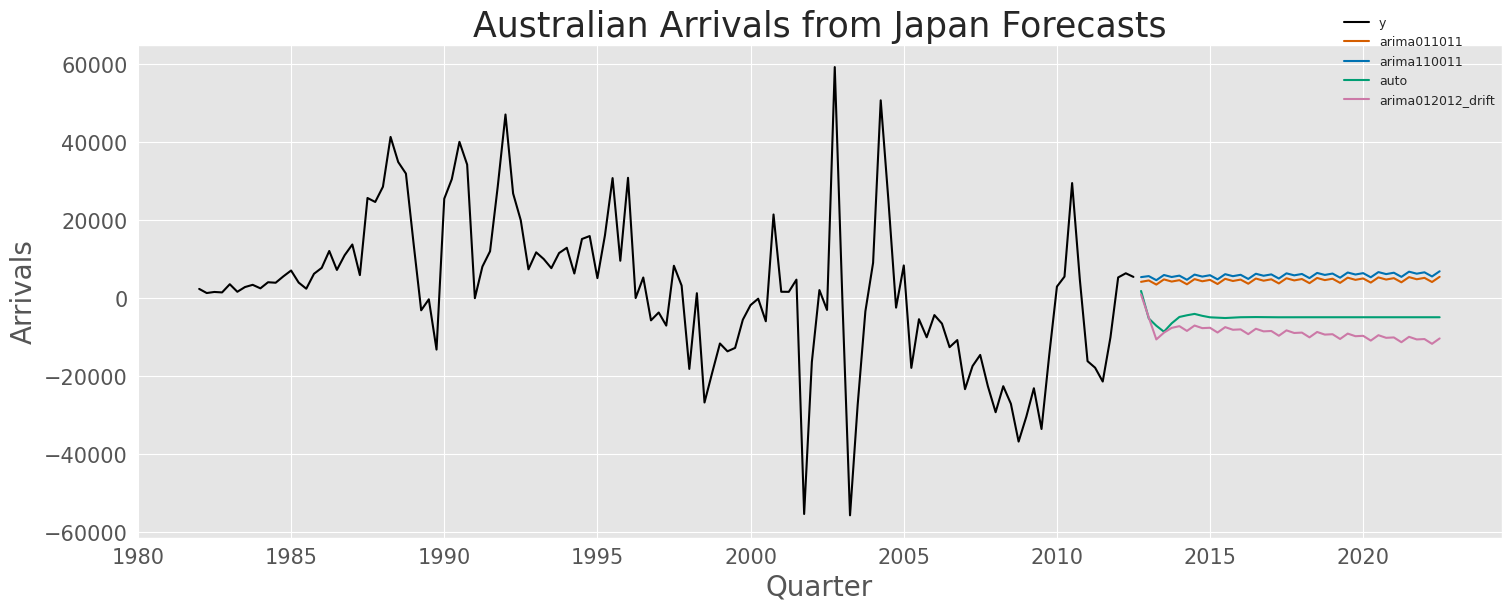

In [75]:
forecast = sf.forecast(h=40, df=differenced_df, fitted=True)
fig = plot_series(differenced_df, forecast,title="Australian Arrivals from Japan Forecasts", xlabel="Quarter", ylabel="Arrivals", 
                  palette = "black_and_4color", rm_legend=False)
display(fig)

g. Write the best model in terms of the backshift operator, then without using the backshift operator.
ARIMA(0,1,2)(0,1,2)[4] with drift.

Backshift operator: $$(1-B) (1-B^4)y_t = c + (1+\theta_1 B + \theta_2 B^2) + (1+\Theta_1 B^4+\Theta_2 B^8)\epsilon_t $$

Without Backshift operator: 
$$y_t =
y_{t-1}
+ y_{t-4}
- y_{t-5}
+ c
+ \varepsilon_t
+ \theta_1\varepsilon_{t-1}
+ \theta_2\varepsilon_{t-2}
+ \Theta_1\varepsilon_{t-4}
+ \theta_1\Theta_1\varepsilon_{t-5}
+ \theta_2\Theta_1\varepsilon_{t-6}
+ \Theta_2\varepsilon_{t-8}
+ \theta_1\Theta_2\varepsilon_{t-9}
+ \theta_2\Theta_2\varepsilon_{t-10}
$$

> One nuance: with both ordinary and seasonal differencing, “drift” can behave differently depending on software. But for the exercise notation, representing it as \(c\) on the differenced equation is fine.

#### 10. Choose a series from `us_employment`, the total employment in different industries in the United States.

a. Produce an MSTL decomposition of the data and describe the trend and seasonality.

b. Do the data need transforming? If so, find a suitable transformation.

c. Are the data stationary? If not, find an appropriate differencing which yields stationary data.

d. Identify a couple of ARIMA models that might be useful in describing the time series. Which of your models is the best according to their AICc values?

e. Estimate the parameters of your best model and do diagnostic testing on the residuals. Do the residuals resemble white noise? If not, try to find another ARIMA model which fits better.

f. Forecast the next 3 years of data. Get the latest figures from https://fred.stlouisfed.org/categories/11 to check the accuracy of your forecasts.

g. Eventually, the prediction intervals are so wide that the forecasts are not particularly useful. How many years of forecasts do you think are sufficiently accurate to be usable?


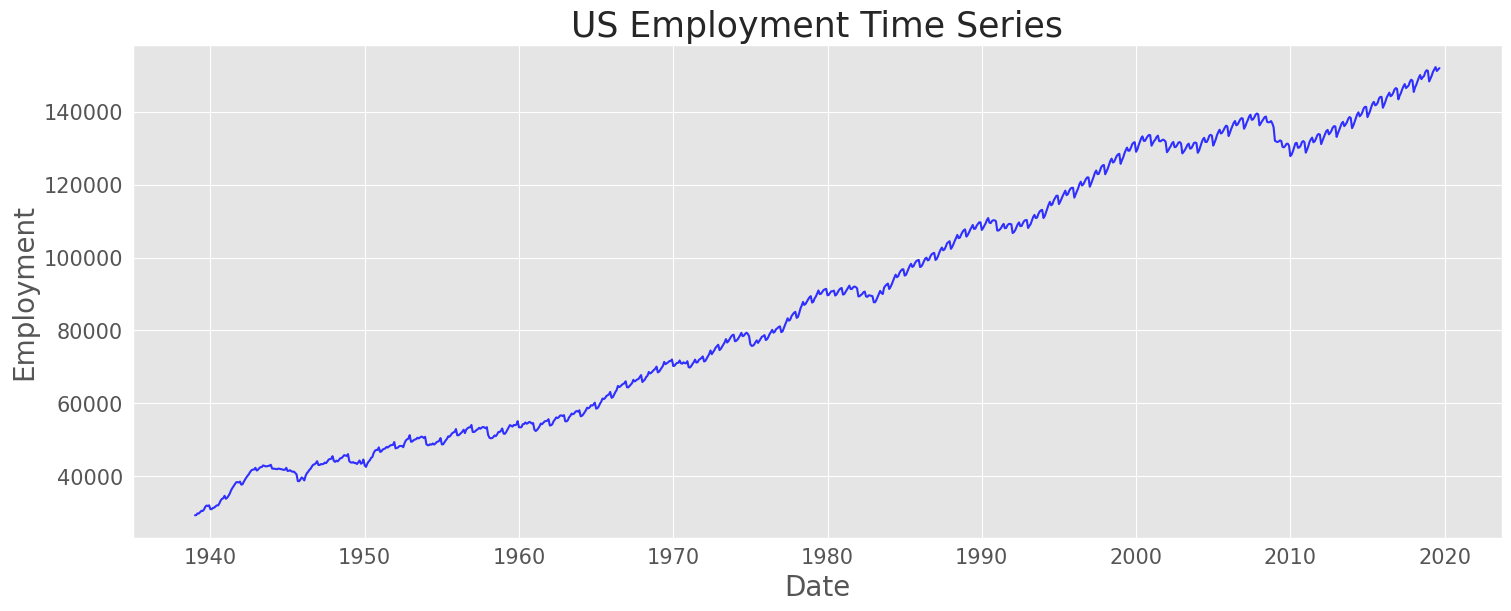

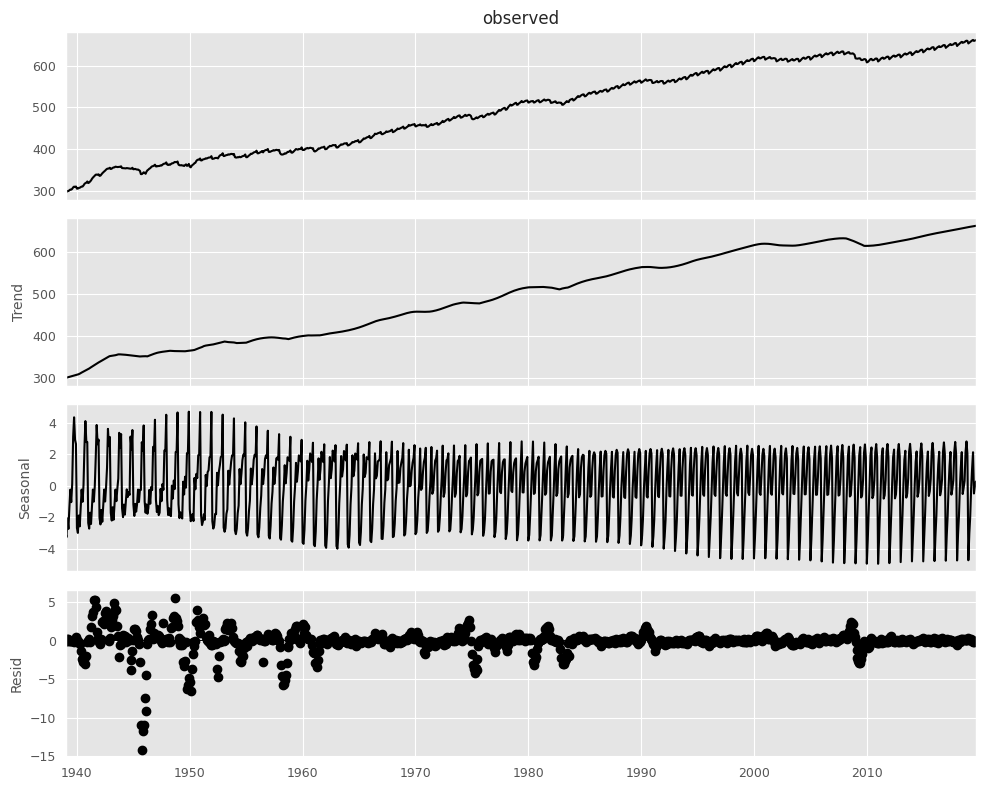

In [76]:
us_employment = (
    pd.read_csv(DATA_DIR / "us_employment.csv", parse_dates=["ds"])
    .query("unique_id == 'All Employees, Total Nonfarm'")
    .reset_index(drop=True)
)
fig = plot_series(us_employment, title="US Employment Time Series", xlabel="Date", ylabel="Employment")
display(fig)

# transforming 
ser = us_employment.set_index('ds')['y']
mstl = MSTL(ser, periods=12, stl_kwargs={"robust": True}, lmbda = "auto") # use transformation to stabilize variance
res = mstl.fit()
fig = res.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()
# store the transformed series in a new DataFrame
transformed_employment = us_employment.copy()
transformed_employment["y"] = res.observed.values

Text(0.5, 1.0, 'PACF')

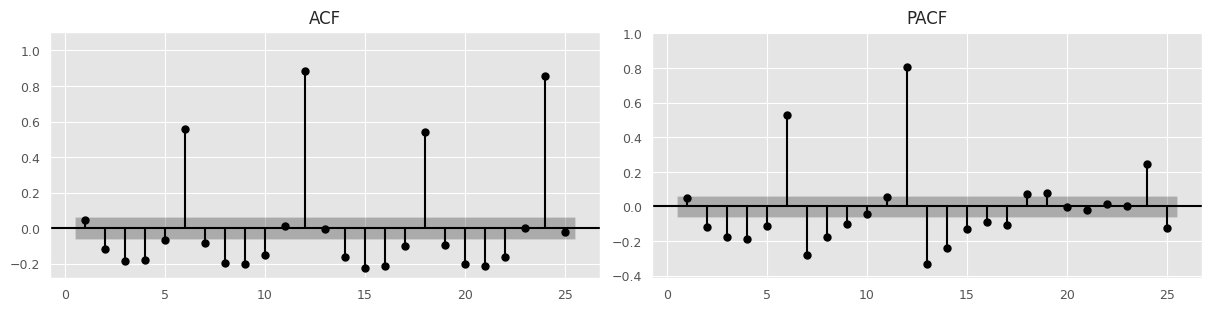

In [77]:
# differencing
differenced_y = transformed_employment["y"].diff().dropna()
differenced_df = pd.DataFrame({
    "unique_id": transformed_employment["unique_id"].iloc[1:].values,
    "ds": transformed_employment["ds"].iloc[1:].values,
    "y": differenced_y.values
})

# plot_series(differenced_df, title="Differenced US Employment Time Series", xlabel="Date", ylabel="Differenced Employment")
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
fig2 = plot_acf(
    differenced_df["y"],
    ax = axes[0],
    lags=25,
    zero=False,
    bartlett_confint=False,
    auto_ylims=True
)
axes[0].set_title("ACF")
fig3 = plot_pacf(  
    differenced_df["y"],
    ax = axes[1],
    lags=25,
    zero=False,
    auto_ylims=True
)  
axes[1].set_title("PACF")

In [78]:
models = [AutoARIMA(stepwise=True, seasonal=True, alias="AutoARIMA"),
        ARIMA(order=(0,1,1), seasonal_order=(0,1,1), include_drift=True, season_length=12, alias="ARIMA(0,1,1)(0,1,1)[12]"),
        ARIMA(order=(1,1,0), seasonal_order=(0,1,1), include_drift=True,  season_length=12, alias="ARIMA(1,1,0)(0,1,1)[12]"),
]

sf = StatsForecast(models=models, freq="M", n_jobs=-1)
sf.fit(df=differenced_df)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,"ARIMA(0,1,1)(0,1,1)[12]","ARIMA(0,1,1)(0,1,1)[12]",0.624,-1132.625,2271.249,2271.275,2285.835
1,"ARIMA(1,1,0)(0,1,1)[12]","ARIMA(1,1,0)(0,1,1)[12]",0.705,-1190.194,2386.388,2386.414,2400.973
2,AutoARIMA,"ARIMA(2,0,5) with non-zero mean",4.084,-2051.848,4121.695,4121.883,4165.573


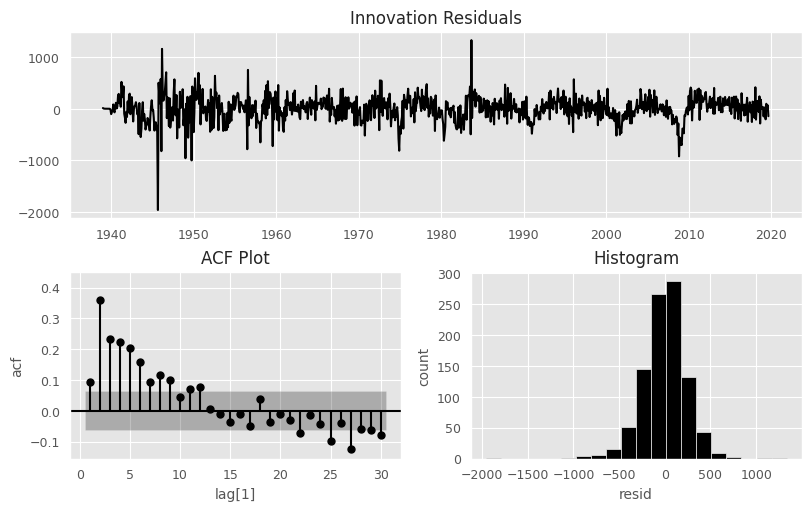

In [79]:
model = ARIMA(
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1),
    season_length=12,
    include_drift=True,
    alias="ARIMA(0,1,1)(0,1,1)[12]"
)

sf = StatsForecast(
    models=[model],
    freq="MS",
    n_jobs=1
)

forecast = sf.forecast(
    df=us_employment,
    h=38,
    level = [80, 95],
    fitted=True
)

res = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["ARIMA(0,1,1)(0,1,1)[12]"]
)

fig = plot_diagnostics(res)

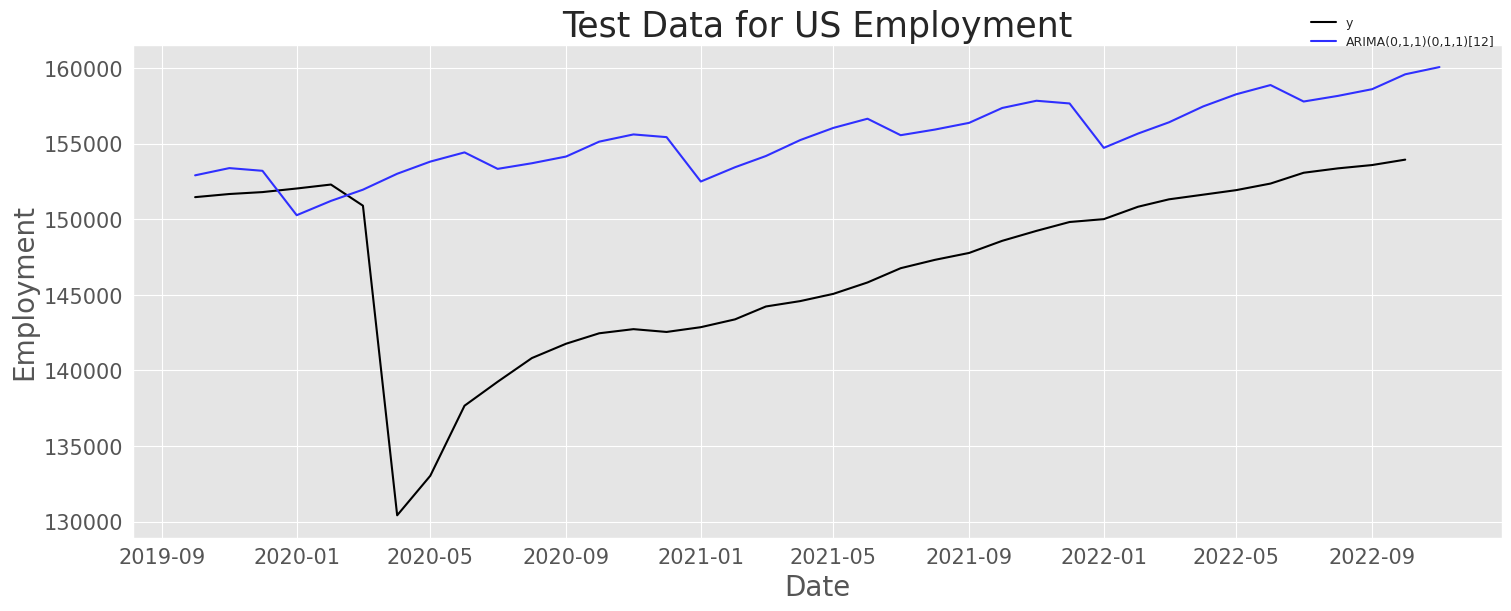

In [80]:
test = (
    pd.read_csv(DATA_DIR / "test.csv", parse_dates=["observation_date"])
    .assign(unique_id="All Employees, Total Nonfarm")
    .rename(columns={"observation_date": "ds", "PAYEMS": "y"})   
    .reset_index(drop=True) 
)

plot_series(test, forecast, title="Test Data for US Employment", xlabel="Date", ylabel="Employment", rm_legend=False)
# res = np.sum((test['y'] - forecast['ARIMA(0,1,1)(0,1,1)[12]']) ** 2) / len(test)
# print(f"RMSE: {res:.4f}")


In [81]:
# test_1_year = (pd.read_csv(DATA_DIR / "test_1_year.csv", parse_dates=["observation_date"])
#     .assign(unique_id="All Employees, Total Nonfarm")
#     .rename(columns={"observation_date": "ds", "PAYEMS": "y"})
#     .reset_index(drop=True)
# )

# plot_series(test_1_year, forecast, title="Test Data for US Employment", xlabel="Date", ylabel="Employment", rm_legend=False)
# res = np.sum((test_1_year['y'] - forecast['ARIMA(0,1,1)(0,1,1)[12]']) ** 2) / len(test_1_year)
# print(f"RMSE: {res:.4f}")

#### 11. Choose one of the following seasonal time series: the Australian production of electricity, cement, or gas (from `aus_production`).

a. Do the data need transforming? If so, find a suitable transformation.

b. Are the data stationary? If not, find an appropriate differencing which yields stationary data.

c. Identify a couple of ARIMA models that might be useful in describing the time series. Which of your models is the best according to their AIC values?

d. Estimate the parameters of your best model and do diagnostic testing on the residuals. Do the residuals resemble white noise.If not, try to find another ARIMA model which fits better.

e. Forecast the next 24 months of data using your preferred model.

f. Compare the forecasts obtained using `AutoETS()`.

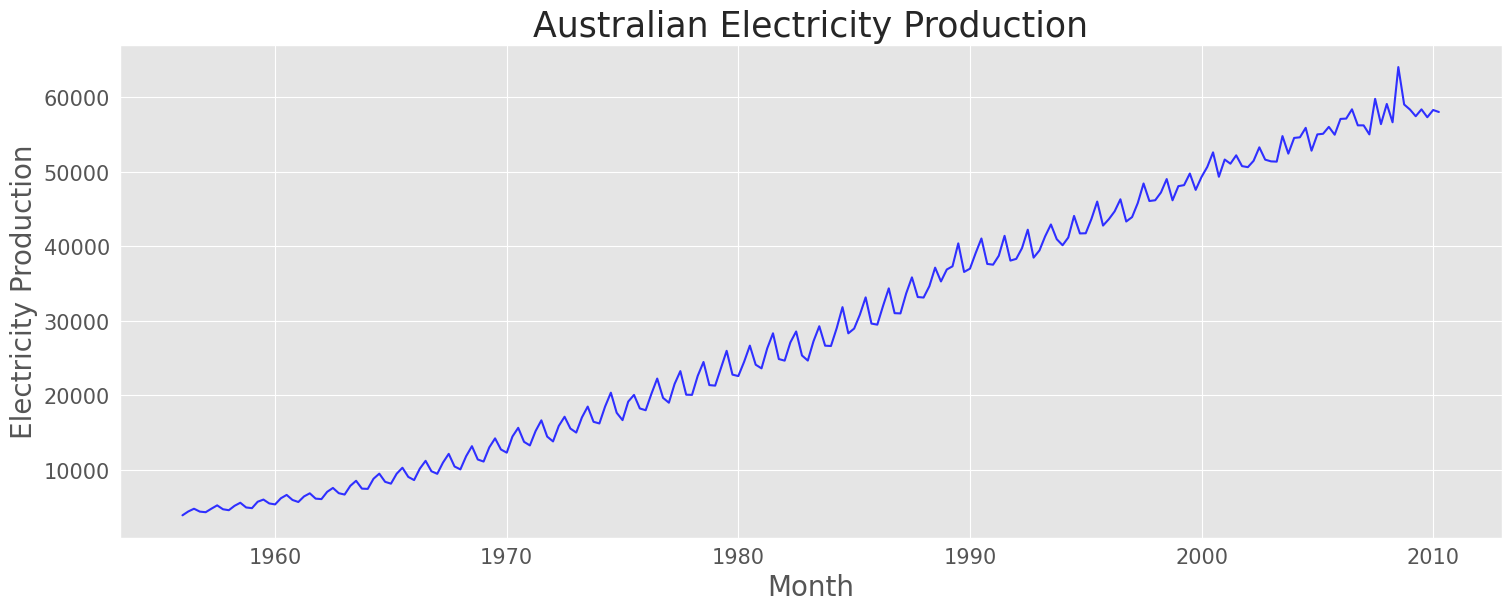

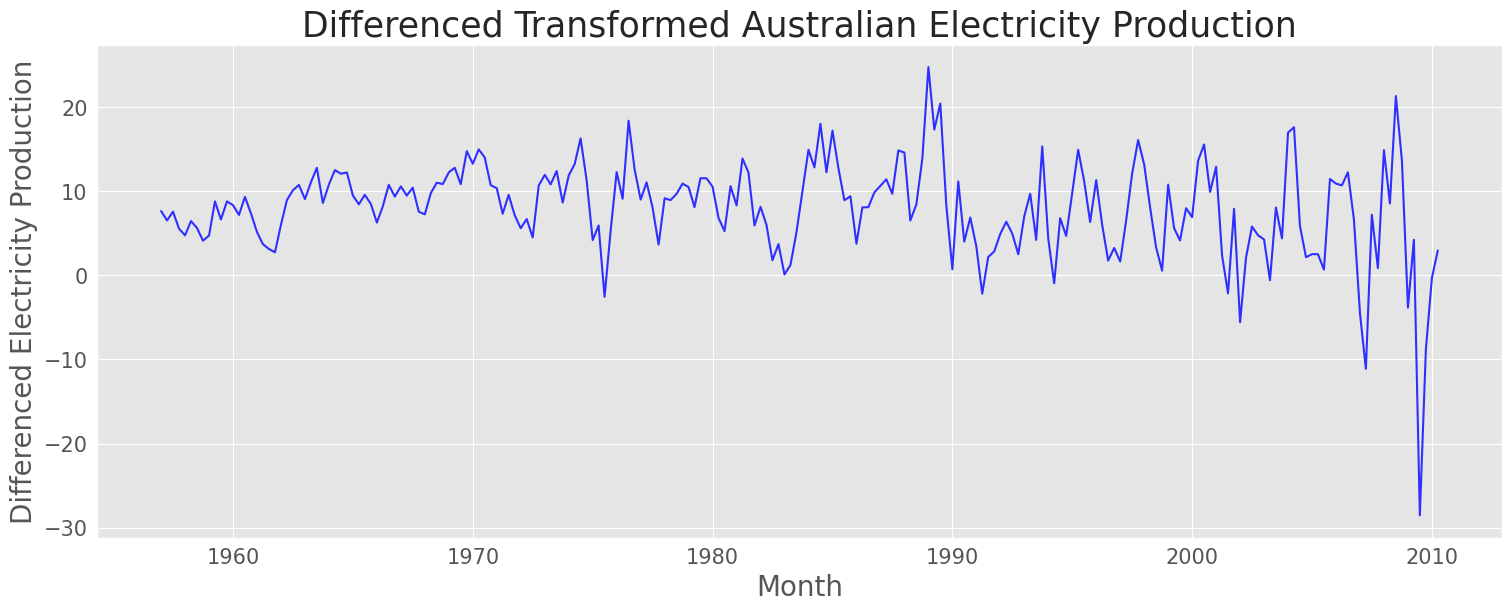

In [82]:
aus_production = (pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=["ds"])
    .rename(columns={"Month": "ds", "Electricity": "y"})
    .assign(unique_id="Electricity")
    [["unique_id", "ds", "y"]]
)
fig = plot_series(aus_production, title="Australian Electricity Production", xlabel="Month", ylabel="Electricity Production")
display(fig)

y = aus_production["y"].to_numpy()
optim_lambda = boxcox_lambda(y, method="guerrero", season_length=4)
y_boxcox = boxcox(y, optim_lambda)

transformed_df = pd.DataFrame({
    "unique_id": aus_production["unique_id"],
    "ds": aus_production["ds"],
    "y": y_boxcox
})

differenced_y = transformed_df["y"].diff(4).dropna()
differenced_df = pd.DataFrame({
    "unique_id": transformed_df["unique_id"].iloc[4:].values,
    "ds": transformed_df["ds"].iloc[4:].values,
    "y": differenced_y.values
})

fig1 = plot_series(differenced_df, title="Differenced Transformed Australian Electricity Production", xlabel="Month", ylabel="Differenced Electricity Production")
display(fig1)

In [83]:
models = [AutoARIMA(stepwise=True, seasonal=True, alias="AutoARIMA", season_length=4),
        ARIMA(order=(0,1,1), seasonal_order=(0,1,1), season_length=4, alias="ARIMA(0,1,1)(0,1,1)[4]"),
        ARIMA(order=(1,1,0), seasonal_order=(0,1,1), season_length=4,  alias="ARIMA(1,1,0)(0,1,1)[4]"),
        ARIMA(order=(0,1,2), seasonal_order=(0,1,2), season_length=4, alias="ARIMA(0,1,2)(0,1,2)[4]")]   
sf = StatsForecast(models=models, freq="QS", n_jobs=-1)
sf.fit(df=differenced_df)
summaries = []
for model in sf.fitted_[0]:
        summary_model = {
                "model": model,
                "Orders": ARIMASummary(model.model_),
                "sigma2": model.model_["sigma2"],
                "loglik": model.model_["loglik"],
                "aic": model.model_["aic"],
                "aicc": model.model_["aicc"],
                "bic": model.model_["bic"],
        }
        summaries.append(summary_model) 
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))



,model,Orders,sigma2,loglik,aic,aicc,bic
0,"ARIMA(0,1,2)(0,1,2)[4]","ARIMA(0,1,2)(0,1,2)[4]",18.289,-609.248,1228.497,1228.792,1245.208
1,AutoARIMA,"ARIMA(0,1,1)(2,0,2)[4]",17.928,-609.417,1230.833,1231.241,1251.001
2,"ARIMA(0,1,1)(0,1,1)[4]","ARIMA(0,1,1)(0,1,1)[4]",29.306,-655.019,1316.039,1316.156,1326.066
3,"ARIMA(1,1,0)(0,1,1)[4]","ARIMA(1,1,0)(0,1,1)[4]",29.697,-655.979,1317.958,1318.075,1327.985


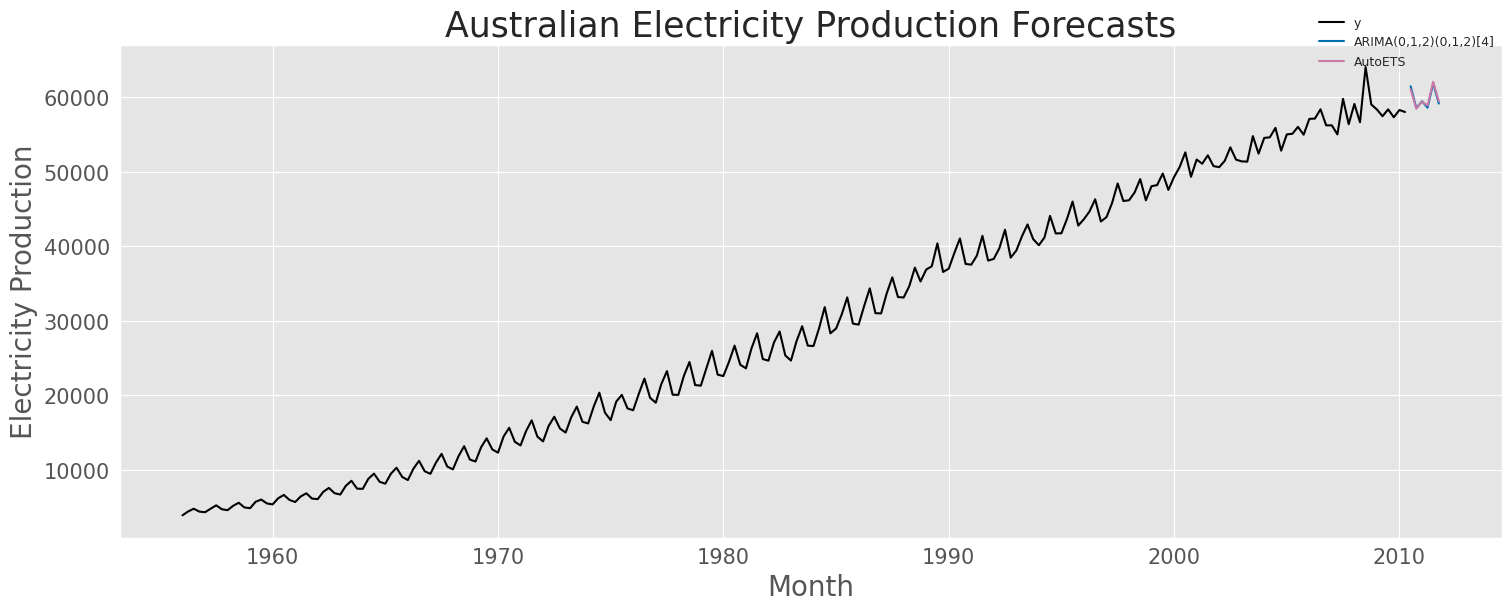

,unique_id,metric,"ARIMA(0,1,2)(0,1,2)[4]",AutoETS
0,Electricity,rmse,717.932,721.064
1,Electricity,mae,469.341,488.172


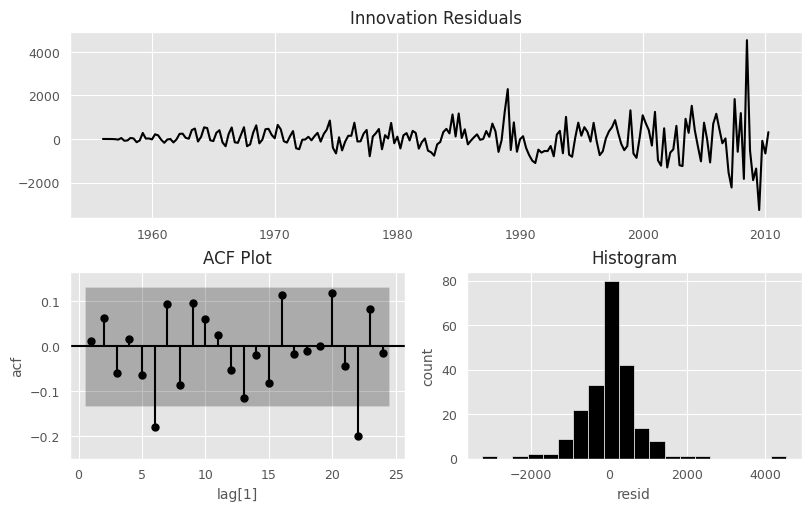

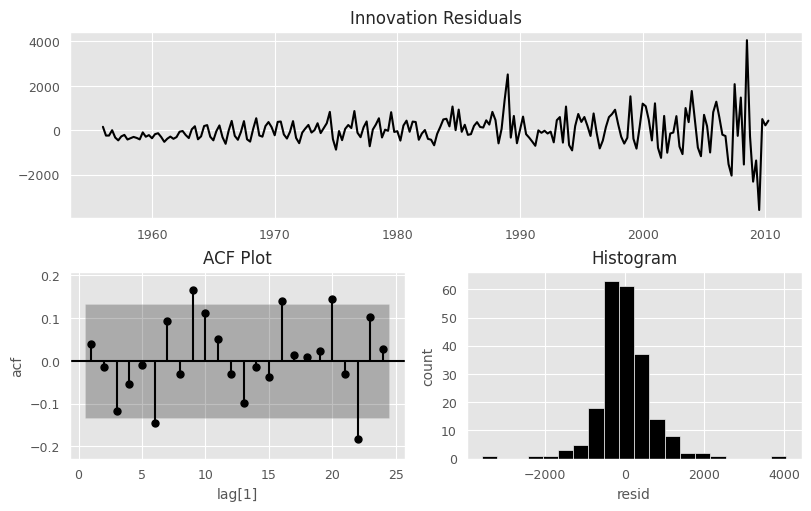

In [84]:
model = [ARIMA(
    order=(0, 1, 2),
    seasonal_order=(0, 1, 2),
    season_length=4,
    include_drift=True,
    alias="ARIMA(0,1,2)(0,1,2)[4]"
),
AutoETS(model="AAA", season_length=4, alias="AutoETS")]

sf = StatsForecast(
    models=model,
    freq="QS",
    n_jobs=1
)

forecast = sf.forecast(
    df=aus_production,
    h=6,
    level = [80, 95],
    fitted=True
)

res = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["ARIMA(0,1,2)(0,1,2)[4]"]
)
res1 = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["AutoETS"]
)
fig = plot_diagnostics(res)
fig1 = plot_diagnostics(res1)

fig2 = plot_series(aus_production, forecast, title="Australian Electricity Production Forecasts", xlabel="Month", ylabel="Electricity Production",
                  palette = "black_and_4color", rm_legend=False)
display(fig2)

fitted_values = sf.forecast_fitted_values()
evaluation = evaluate(fitted_values, metrics=[rmse, mae], models = ['ARIMA(0,1,2)(0,1,2)[4]', 'AutoETS'])
display(evaluation)

In [85]:
len(differenced_df)

214

Forecasts of the ARIMA model is a bit better than the one of the ETS models according the evaluation metrics.

With the residuals dianogtic plots, the ARIMA plots are nearly white noise, but has only lags strike that presents seasonality.

#### 12. For the same time series you used in the previous exercise, try using a non-seasonal model applied to the seasonally adjusted data obtained from the MSTL. Compare the forecasts with those obtained in the previous exercise. Which do you think is the best approach?

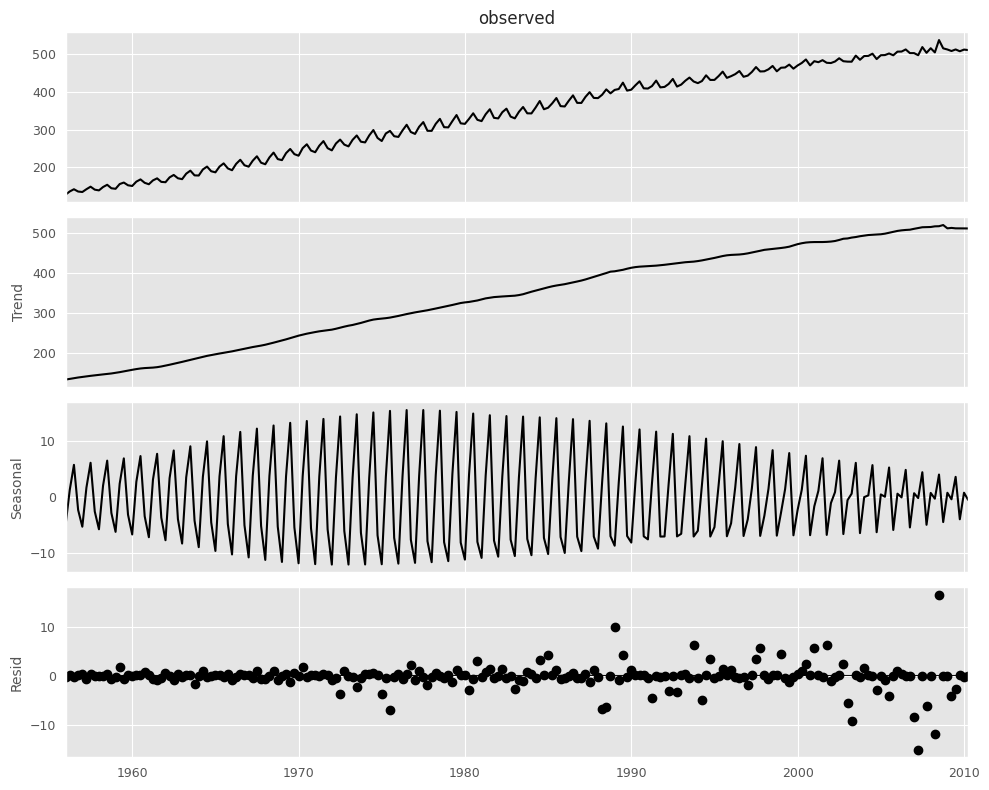

In [86]:
mstl = MSTL(transformed_df.set_index("ds")['y'], periods=4, stl_kwargs={"robust": True}, lmbda = "auto")# use transformation to stabilize variance
res = mstl.fit()
fig = res.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

In [87]:
seasonally_adjusted = res.observed - res.seasonal
seasonally_adjusted_df = aus_production.copy()
seasonally_adjusted_df["y"] = seasonally_adjusted.values

seasonally_adjusted_df = seasonally_adjusted_df.loc[4:].reset_index(drop=True)

models = [
    AutoARIMA(stepwise=True, seasonal=False, alias="AutoARIMA"),
    ARIMA(order=(0, 1, 2), alias="ARIMA(0,1,2)")
]

sf = StatsForecast(models=models, freq="QS", n_jobs=1)
sf.fit(df=seasonally_adjusted_df)

summaries = []

for fitted_model in sf.fitted_[0]:
    m = fitted_model.model_

    summaries.append({
        "model": fitted_model.alias,
        "Orders": ARIMASummary(m),
        "sigma2": m["sigma2"],
        "loglik": m["loglik"],
        "aic": m["aic"],
        "aicc": m["aicc"],
        "bic": m["bic"],
    })

pd.DataFrame(summaries).sort_values("aicc")

,model,Orders,sigma2,loglik,aic,aicc,bic
0,AutoARIMA,"ARIMA(0,1,1) with drift",12.804,-572.892,1151.784,1151.899,1161.868
1,"ARIMA(0,1,2)","ARIMA(0,1,2)",17.547,-606.372,1218.743,1218.858,1228.827


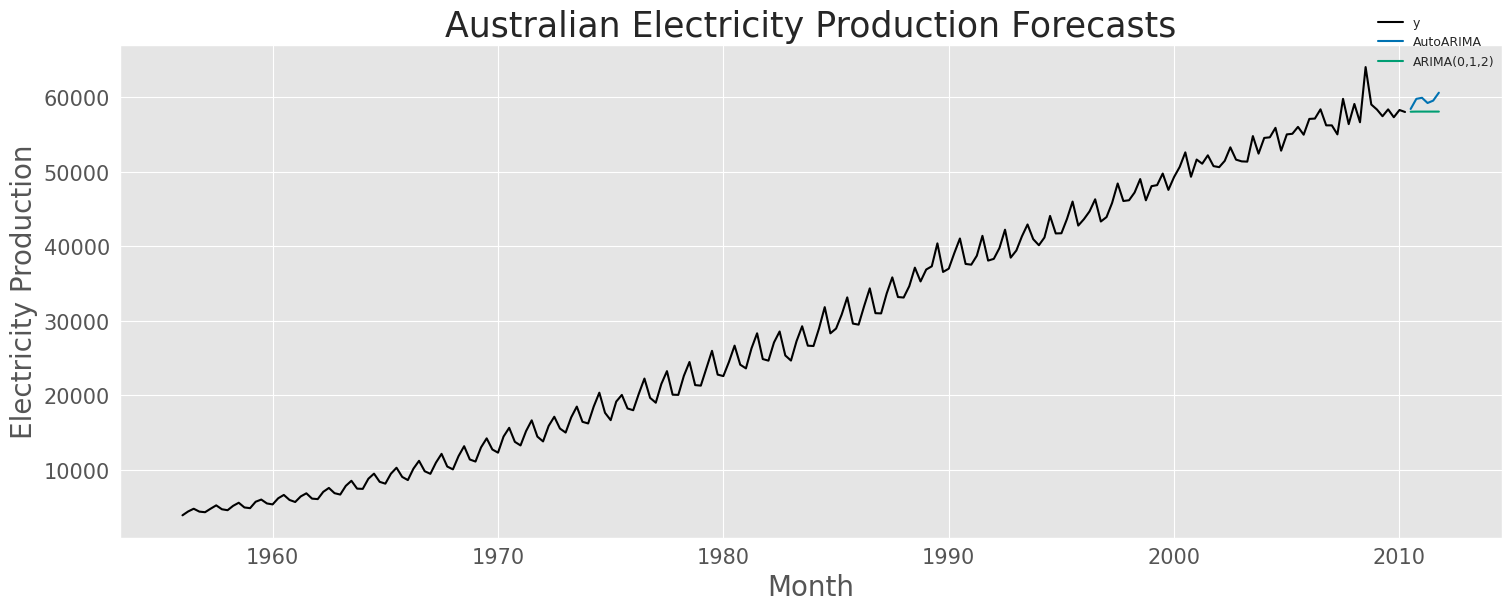

,unique_id,metric,"ARIMA(0,1,2)",AutoARIMA
0,Electricity,rmse,1644.236,1121.286
1,Electricity,mae,1324.111,776.161


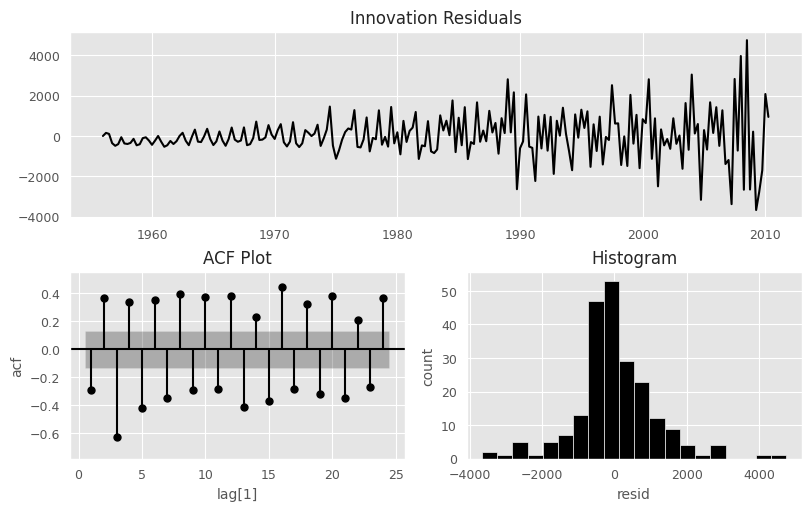

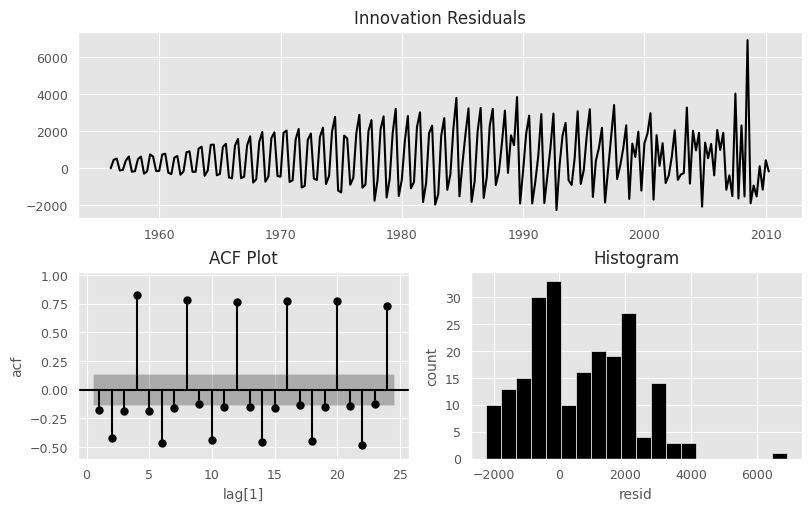

In [88]:
forecast = sf.forecast(
    df=aus_production,
    h=6,
    fitted=True
)

res = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["AutoARIMA"]
)
res1 = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["ARIMA(0,1,2)"]
)
fig = plot_diagnostics(res)
fig1 = plot_diagnostics(res1)

fig2 = plot_series(aus_production, forecast, title="Australian Electricity Production Forecasts", xlabel="Month", ylabel="Electricity Production",
                  palette = "black_and_3color", rm_legend=False)
display(fig2)

fitted_values = sf.forecast_fitted_values()
evaluation = evaluate(fitted_values, metrics=[rmse, mae], models = ['ARIMA(0,1,2)', 'AutoARIMA'])
display(evaluation)

Process 1: transform + difference

Process 2: transform + seasonal adjustment

> Which is better?
* There is no automatic winner. I would compare them using out-of-sample forecast accuracy, not only AICc.
* Use:MAE, RMSE, MASE, sMAPE on a test set or cross-validation.
* A practical rule:
    * If seasonality is stable and simple, SARIMA on transformed original data is often effective.
    * If seasonality changes over time or is complex, MSTL seasonal adjustment + nonseasonal model can be better.
    * If your goal is interpretability, seasonal adjustment is easier to explain.
    * If your goal is pure forecasting accuracy, test both and choose the lower out-of-sample error.
> Important: do not compare AICc across these two processes too strongly, because they are fitted to different transformed target series. AICc is safest when comparing models on the same response variable.

With above dataset, process 1 is better apperently.

#### 13. For the Australian tourism data (from `tourism`):

a. Fit ARIMA models for each time series.

b. Produce forecasts of your fitted models.

c. Check the forecasts for the “Snowy Mountains” and “Melbourne” regions. Do they look reasonable?



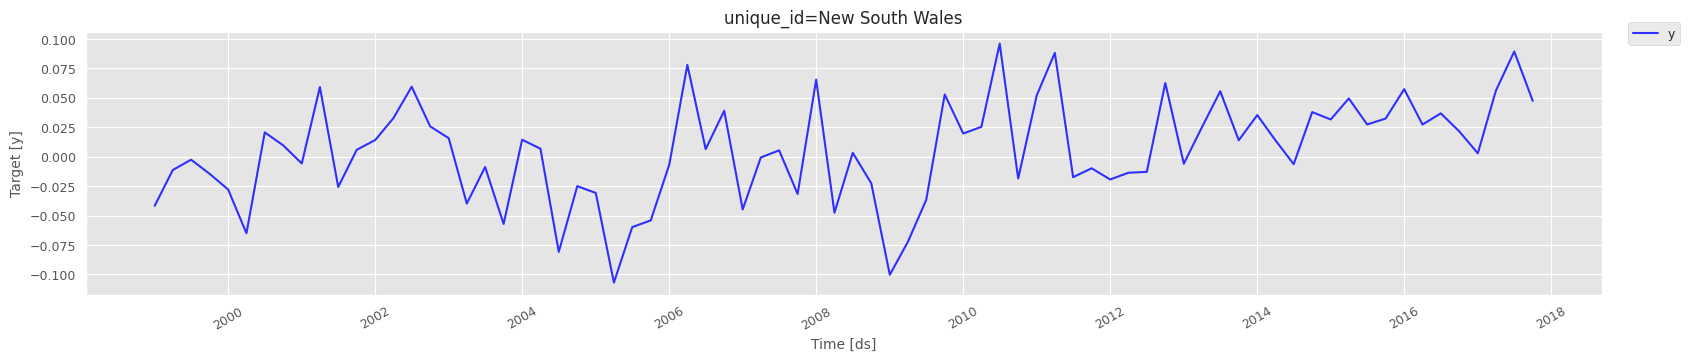

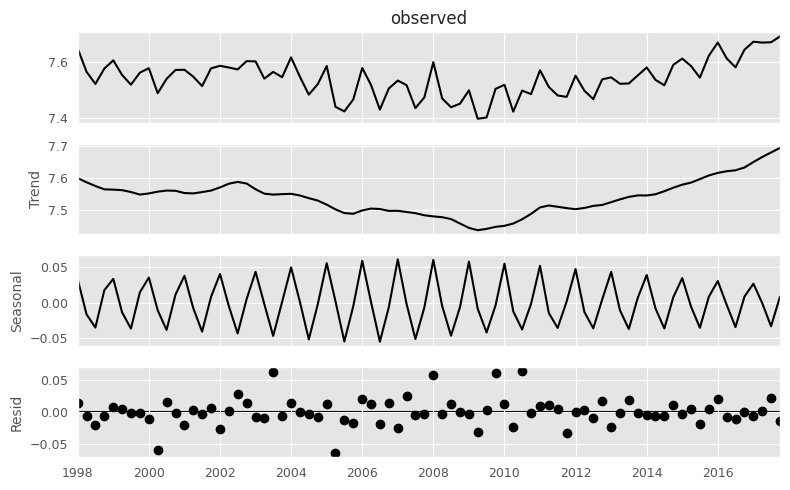

In [93]:
from utilsforecast.plotting import plot_series


nsw_df = (
    pd.read_csv(DATA_DIR / "tourism.csv", parse_dates=["ds"])
    .query("State == 'New South Wales'")
    .groupby(["State", "ds"], as_index=False)["y"].sum()
    .rename(columns={"State": "unique_id"})
    [["unique_id", "ds", "y"]]
)

vic_df = (
    pd.read_csv(DATA_DIR / "tourism.csv", parse_dates=["ds"])
    .query("State == 'Victoria'")
    .groupby(["State", "ds"], as_index=False)["y"].sum()
    .rename(columns={"State": "unique_id"})
    [["unique_id", "ds", "y"]]
)


# fig = plot_series(
#     nsw_df
# )

# display(fig)

mstl = MSTL(nsw_df.set_index("ds")["y"], periods=4, stl_kwargs={"robust": True}, lmbda="auto")
res = mstl.fit()
fig1 = res.plot()

differenced_y = res.observed.diff(4).dropna()
differenced_df = pd.DataFrame({
    "unique_id": nsw_df["unique_id"].iloc[4:].values,
    "ds": nsw_df["ds"].iloc[4:].values,
    "y": differenced_y.values
})

fig2 = plot_series(
    differenced_df,
    # title="Seasonally Differenced Tourism in New South Wales",
    # xlabel="Date",
    # ylabel="Seasonally Differenced Number of Trips"
)
display(fig2)



In [ ]:
models = [
    AutoARIMA(stepwise=True, seasonal=True, alias="AutoARIMA", season_length=4),
    ARIMA(order=(0, 1, 1), seasonal_order=(0, 1, 1), season_length=4, alias="ARIMA(0,1,1)(0,1,1)[4]"),
    ARIMA(order=(1, 1, 0), seasonal_order=(0, 1, 1), season_length=4,  alias="ARIMA(1,1,0)(0,1,1)[4]"),
]
sf = StatsForecast(models=models, freq="QS", n_jobs=-1)
sf.fit(df=differenced_df)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,AutoARIMA,"ARIMA(1,1,0)(2,0,1)[4] with drift",0.001,139.259,-266.518,-265.283,-252.613
1,"ARIMA(0,1,1)(0,1,1)[4]","ARIMA(0,1,1)(0,1,1)[4]",0.002,119.689,-233.379,-233.021,-226.591
2,"ARIMA(1,1,0)(0,1,1)[4]","ARIMA(1,1,0)(0,1,1)[4]",0.002,115.763,-225.525,-225.167,-218.737


,unique_id,metric,AutoARIMA
0,New South Wales,rmse,0.037
1,New South Wales,mae,0.029


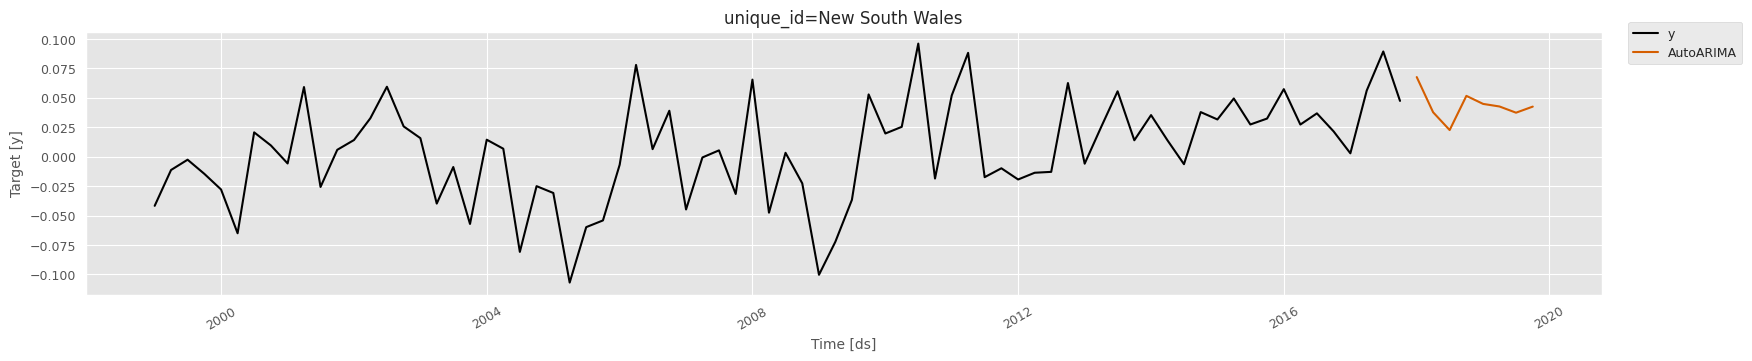

In [102]:
models = [
    AutoARIMA(stepwise=True, seasonal=True, alias="AutoARIMA", season_length=4),]
sf = StatsForecast(models=models, freq="QS", n_jobs=-1)
forecast = sf.forecast(h=8, df=differenced_df, fitted=True)
fitted_values = sf.forecast_fitted_values()
evaluation = evaluate(fitted_values, metrics=[rmse, mae], models = ['AutoARIMA'])
display(evaluation)
plot_series(
    differenced_df,
    forecast,
    # title="Seasonally Differenced Tourism in New South Wales with Forecasts",
    # xlabel="Date",
    # ylabel="Seasonally Differenced Number of Trips",
    palette = "black_and_2color",
    # rm_legend=False
)


#### 14. For your retail time series (Exercise 5 above):

a. Develop an appropriate seasonal ARIMA model;

b. Compare the forecasts with those you obtained in earlier chapters;

c. Obtain up-to-date retail data from the ABS website (Cat 8501.0, Table 11), and compare your forecasts with the actual numbers. How good were the forecasts from the various models?

#### 15. Consider the number of Snowshoe Hare furs traded by the Hudson Bay Company between 1845 and 1935 (data set `pelt`).

a. Produce a time plot of the time series.

b. Assume you decide to fit the following model:
$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \phi_3 y_{t-3} + \phi_4 y_{t-4} + \epsilon_t$$
Where $\epsilon_t$  is a white noise series. What sort of ARIMA model is this (i.e., what are $p,d,q$?

c. By examining the ACF and PACF of the data, explain why this model is appropriate.

d. The last five values of the series are given below:
|Year|1931|1932|1933|1934|1935|
|--|--|--|--|--|--|
|Number of hare pelts|19520|82110|89760|81660|15760|

The estimated parameters are $c = 30993, \phi_1 = 0.82, \phi_2 = -0.29, \phi_3 = -0.01$ and $\phi_4 = -0.22$. Calculate the forecasts for the next three years (1936–1939) using this model.

e. Now fit the model and obtain forecasts with StatsForecast. How are they different from yours? Why?

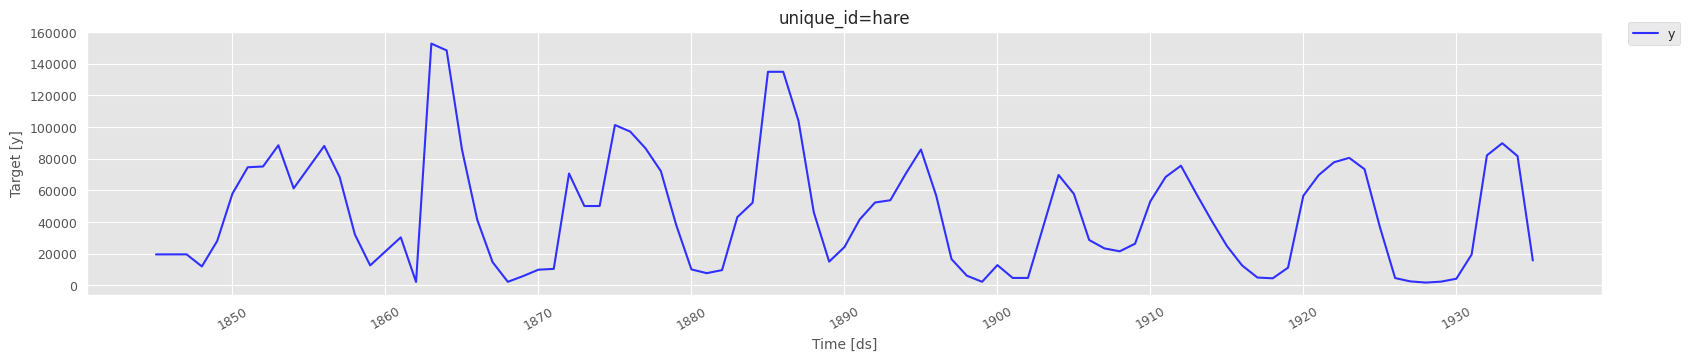

In [118]:
hare = (pd.read_csv(DATA_DIR / "pelt.csv", parse_dates=["ds"])
    .query("unique_id == 'hare'")
    .reset_index(drop=True)
)
fig = plot_series(hare, 
                #title="Hare Population Time Series", xlabel="Year", ylabel="Population"
                )
display(fig)

length = len(hare)
train = hare.iloc[:int(length - 10)]
test = hare.iloc[int(length - 10):]

,unique_id,metric,"ARIMA(4,0,0)"
0,hare,rmse,23392.641
1,hare,mae,15919.925


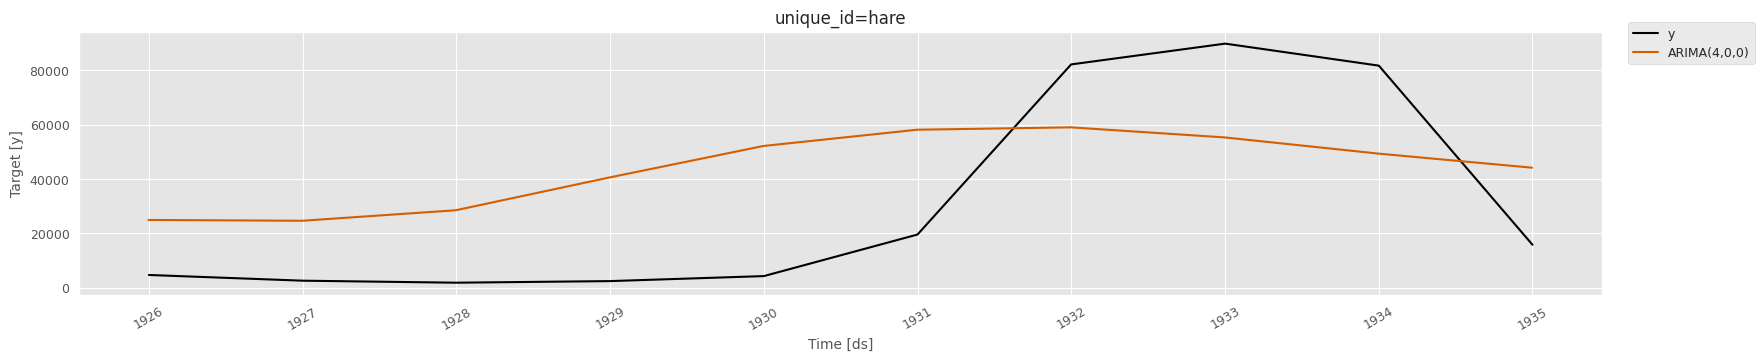

In [119]:
model = [ARIMA(order = (4,0,0), alias = "ARIMA(4,0,0)")]
sf = StatsForecast(models=model, freq="Y", n_jobs=1)
forecast = sf.forecast(h=10, df=train, fitted=True) 
fitted_values = sf.forecast_fitted_values()
evaluation = evaluate(fitted_values, metrics=[rmse, mae], models = ['ARIMA(4,0,0)'])
display(evaluation)

fig2 = plot_series(test, forecast,
                # title="Hare Population Time Series with Forecasts", xlabel="Year", ylabel="Population",
                palette = "black_and_2color",
                # rm_legend=False
                )
display(fig2)

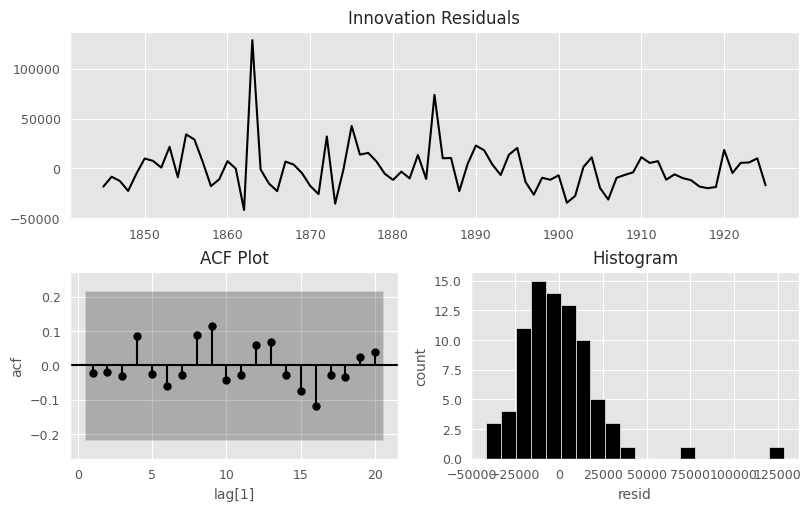

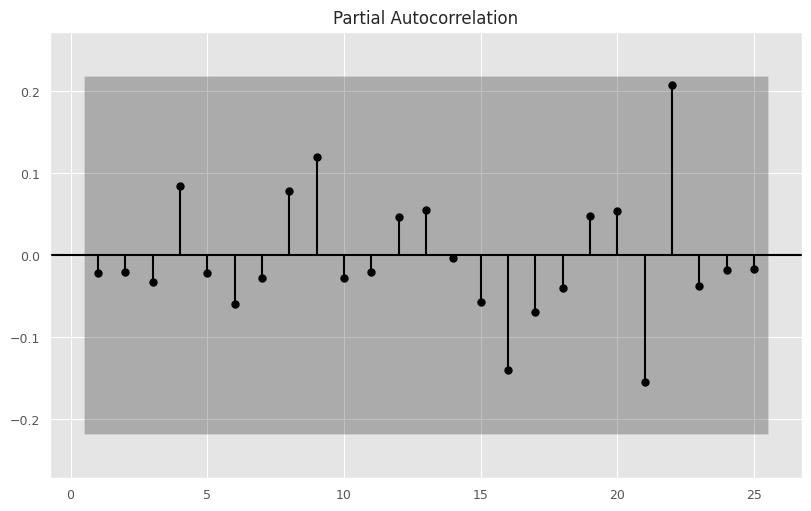

In [122]:
res = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["ARIMA(4,0,0)"]
)
fig3 = plot_diagnostics(res)

fig4 = plot_pacf(
    res["resid"].dropna(),
    lags=25,
    zero=False,
    auto_ylims=True
)


* The PACF suggests an autoregressive model because the main dependence appears in the early lags and then largely dies out, with most later lags inside the confidence bounds. Since the model includes four lagged values of y, this corresponds to an AR(4).
* The residual ACF shows no strong remaining autocorrelation, so the fitted model leaves residuals that are approximately white noise. The AR(4) model appears to have captured most of the time dependence. 

> Therefore an ARIMA(4,0,0) model is appropriate. 

In [143]:
# Last observed values
y = {
    1931: 19520,
    1932: 82110,
    1933: 89760,
    1934: 81660,
    1935: 15760,
}

# Estimated parameters
c = 30993
phi1 = 0.82
phi2 = -0.29
phi3 = -0.01
phi4 = -0.22

# Recursive forecasts
for year in range(1936, 1940):
    y[year] = (
        c
        + phi1 * y[year - 1]
        + phi2 * y[year - 2]
        + phi3 * y[year - 3]
        + phi4 * y[year - 4]
    )

# Show forecasts
forecasts = pd.DataFrame({
    "Year": list(range(1936, 1940)),
    "Forecast": [y[year] for year in range(1936, 1940)]
})

In [144]:
# Fit ARIMA(4, 0, 0), i.e. AR(4)
sf = StatsForecast(
    models=[
        ARIMA(order=(4, 0, 0), include_mean=True)
    ],
    freq="YS",
    n_jobs=-1
)

fcst = sf.forecast(
    df=hare,
    h=4
)

#### 16. The population of Switzerland from 1960 to 2017 is in data set `global_economy`.

a. Produce a time plot of the data.

b. You decide to fit the following model to the series:
$$y_t = c + y_{t-1} + \phi_1 (y_{t-1} - y_{t-2}) + \phi_2 (y_{t-2} - y_{t-3}) + \phi_3 (y_{t-3} - y_{t-4}) + \epsilon_t$$

where $y_t$ is the Population in year $t$ and $\epsilon_t$ is a white noise series. What sort of ARIMA model is this (i.e., what are $p,d,q$? 

c. Explain why this model was chosen using the ACF and PACF of the differenced series.

d. The last five values of the series are given below.
|Year|2013|2014|2015|2016|2017|
|--|--|--|--|--|--|
|Population (millions)|8.09|8.19|8.28|8.37|8.47|

The estimated parameters are $c=0.0053, \phi_1=1.64,\phi_2=-1.17,$ and $\phi_3=0.45$. Calculate forecasts for the next three years (2018–2020).

e. Now fit the model with `StatsForecast` and obtain the forecasts from the same model. How are they different from yours? Why?



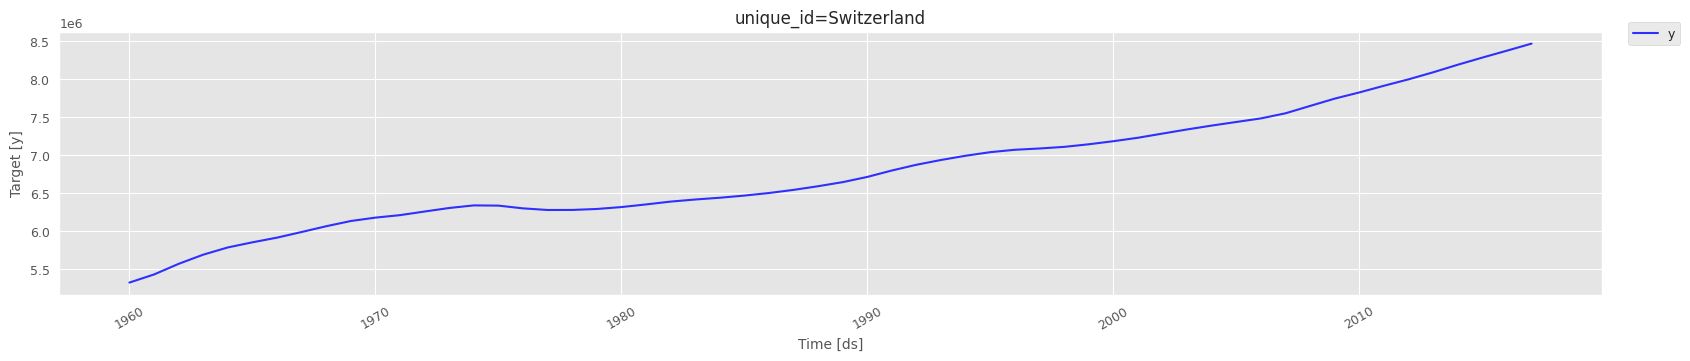

,unique_id,metric,"ARIMA(3,1,0)"
0,Switzerland,rmse,31652.720
1,Switzerland,mae,22550.055


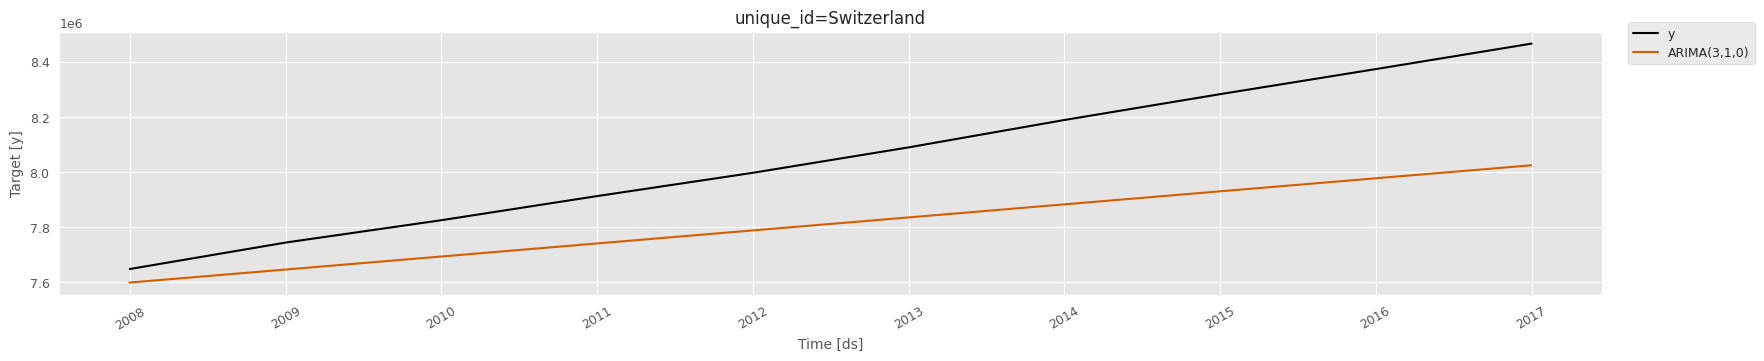

In [171]:
swit = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates=["ds"])
    .query("unique_id == 'Switzerland'").reset_index(drop=True)
    .rename(columns={"Population": "y"})
    [["unique_id", "ds", "y"]]
)
fig = plot_series(swit, 
                  #title="Swiss Population Time Series", xlabel="Year", ylabel="Population"
                  )
display(fig)

train = swit.iloc[:int(len(swit) - 10)]
test = swit.iloc[int(len(swit) - 10):]

# differenced_y = train["y"].diff().dropna()
# differenced_df = pd.DataFrame({
#     "unique_id": train["unique_id"].iloc[1:].values,
#     "ds": train["ds"].iloc[1:].values,
#     "y": differenced_y.values
# })

model = [ARIMA(order = (3,1,0), include_drift=True, alias = "ARIMA(3,1,0)")]
sf = StatsForecast(models=model, freq="Y", n_jobs=1)
forecast = sf.forecast(h=10, df=train, fitted=True)
fitted_values = sf.forecast_fitted_values()
evaluation = evaluate(fitted_values, metrics=[rmse, mae], models = ['ARIMA(3,1,0)'])
display(evaluation)

fig2 = plot_series(test, forecast,
                  # title="Swiss Population Time Series with Forecasts", xlabel="Year", ylabel="Population",
                  palette = "black_and_2color",
                  # rm_legend=False
                  )
display(fig2)

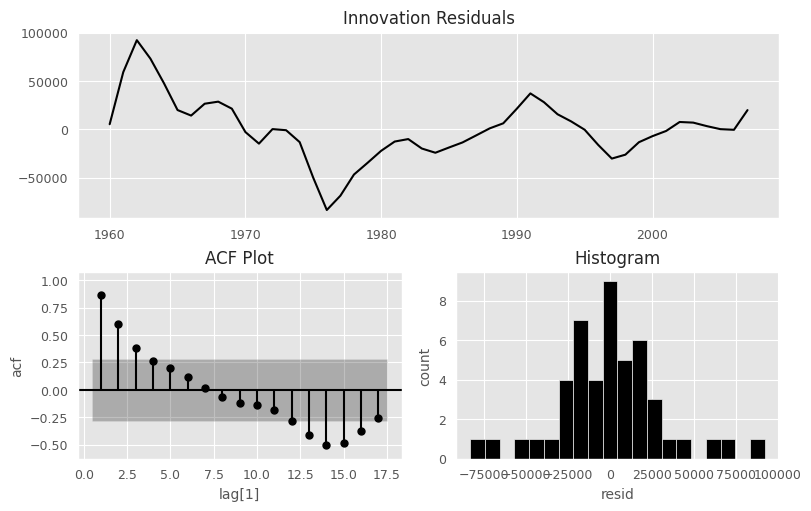

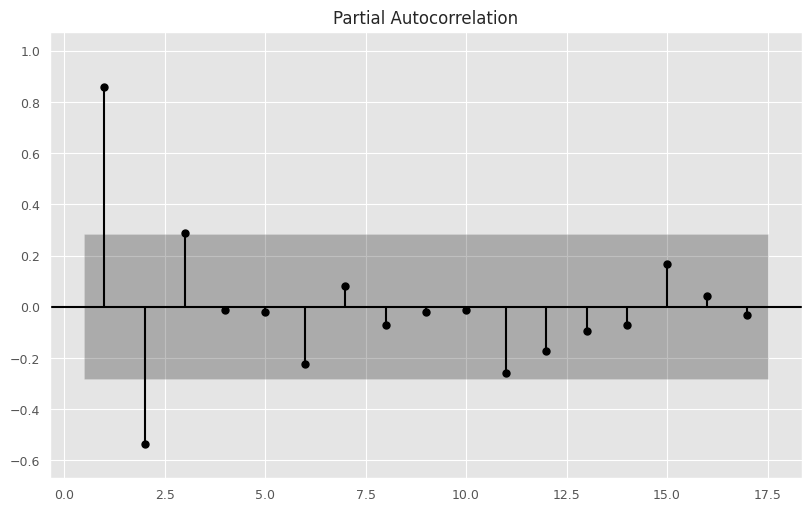

In [172]:
res = sf.forecast_fitted_values().assign(
    resid=lambda x: x["y"] - x["ARIMA(3,1,0)"]
)
fig3 = plot_diagnostics(res)

fig4 = plot_pacf(
    res["resid"].dropna(),
    lags=17.5,
    zero=False,
    auto_ylims=True
)

After first differencing, the ACF decays gradually while the PACF shows the main significant spikes in the first few lags and then mostly cuts off. This is the usual pattern for an autoregressive model on the differenced series. Since the PACF suggests three autoregressive lags, the selected model is ARIMA(3,1,0).

In [175]:
y = {2013:8.09, 
     2014:8.19, 
     2015:8.28, 
     2016:8.37, 
     2017:8.47}

c = 0.0053
p1 = 1.64
p2 = -1.17
p3 = 0.45

for year in range(2018, 2021):
    y[year] = c + p1 * y[year - 1] + p2 * y[year - 2] + p3 * y[year - 3]

# Show forecasts
forecasts = pd.DataFrame({
    "Year": list(range(2018, 2021)),
    "Forecast": [y[year] for year in range(2018, 2021)]
})
forecasts

,Year,Forecast
0,2018,7.829
1,2019,6.702
2,2020,5.648


In [184]:
sf = StatsForecast(
    models=[
        ARIMA(order = (3,1,0), include_mean =True, alias = "ARIMA(3,1,0)")
    ],
    freq="YS",
    n_jobs=-1
)

fcst = sf.forecast(
    df=test,
    h=3
)
fcst

,unique_id,ds,"ARIMA(3,1,0)"
0,Switzerland,2018-01-01,8.535e+06
1,Switzerland,2019-01-01,8.588e+06
2,Switzerland,2020-01-01,8.631e+06
